# Fiber Cut Incident Response — Azure Content Understanding + Agent Demo

**DEM331 — Microsoft Build 2026**

---

## The Scenario

**6:47 AM.** A network operations center alert fires:

> **INC-2026-0391** — Signal degradation detected  
> **Route:** Tower Ridge Corridor, Site B, Segment 9  
> **Impact:** 42 customers at risk (primary + backup share conduit)  
> **Severity:** CRITICAL — no redundancy path available

Manually triaging this incident means opening 9 documents, cross-referencing tables, photos, engineering data, and procurement forms — hours of work before a repair crew can be dispatched.

The **Fiber Cut Response Agent** automates this end-to-end. **Azure Content Understanding** extracts structured intelligence from complex documents, images, audio, and video files. An **LLM agent** then reasons across all of them to produce a diagnosis, materials plan, and dispatch email. Finally, the **Microsoft Agent Framework** shows how to wrap the entire CU lifecycle into a reusable context provider for multi-turn agent conversations.

---

### Overview

| Step | Agent Task | CU Capability |
|------|------------|---------------|
| **Act 1** | Assess incident history | Tables, selection marks, QR codes, signatures |
| **Act 2** | Verify damage visually | Embedded images with AI-generated captions |
| **Act 3** | Extract decision-critical fields | **Custom analyzers** — structured fields with reasoning |
| **Act 4** | Diagnose and dispatch | `to_llm_input()` → agent → diagnosis + dispatch |
| **Act 5** | Agent Framework integration | CU as a **context provider** — automatic analysis, formatting, and multi-turn caching |

### Architecture

```
  Incident Alert            Content Understanding                Agent
  ┌─────────────────┐      ┌──────────────────────┐      ┌───────────────┐
  │ INC-2026-0391   │─────▶│ Layout • Tables      │─────▶│ DIAGNOSE      │
  │                 │      │ Figures • Barcodes   │      │ IDENTIFY      │
  │ 9 Documents     │      │ Custom Fields        │      │ DISPATCH      │
  │ Retrieved       │      │ Classification       │      │               │
  └─────────────────┘      └──────────────────────┘      └───────────────┘
                                      │
                                      ▼
                           ┌──────────────────────┐
                           │ Microsoft Agent      │
                           │ Framework (MAF)      │
                           │ ──────────────────── │
                           │ Context Provider     │
                           │ auto-analyze +       │
                           │ multi-turn cache     │
                           └──────────────────────┘
```

## Setup

In [1]:
%pip install azure-ai-contentunderstanding --pre --quiet
%pip install pymupdf python-dotenv openai --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(override=True)

ENDPOINT = os.environ["CONTENTUNDERSTANDING_ENDPOINT"]
KEY = os.getenv("CONTENTUNDERSTANDING_KEY")
DOCS_DIR = Path("sample-data/documents")

print(f"Endpoint: {ENDPOINT}")
print(f"Auth: {'API Key' if KEY else 'DefaultAzureCredential'}")
print(f"Documents: {len(list(DOCS_DIR.glob('cl_v3_*.pdf')))} PDFs available")

Endpoint: https://mmi-usw3-eft-foundry.services.ai.azure.com/
Auth: API Key
Documents: 9 PDFs available


In [3]:
from azure.ai.contentunderstanding import ContentUnderstandingClient, to_llm_input
from azure.ai.contentunderstanding.models import AnalysisResult, DocumentContent
from azure.core.credentials import AzureKeyCredential
from azure.identity import DefaultAzureCredential

import pymupdf
from IPython.display import display, Image, Markdown

# Initialize CU client
credential = AzureKeyCredential(KEY) if KEY else DefaultAzureCredential()
client = ContentUnderstandingClient(
    endpoint=ENDPOINT,
    credential=credential,
    user_agent="build26-DEM331/1.0.0"
)

print("\u2705 Content Understanding client ready")

✅ Content Understanding client ready


In [4]:
from openai import AzureOpenAI

def sanitize(text: str) -> str:
    """Remove surrogate characters that break Jupyter's ZMQ serialization."""
    return text.encode("utf-8", errors="replace").decode("utf-8")


def show_pdf(pdf_path: Path, dpi: int = 150, max_width: int = 900):
    """Render a PDF page as an inline image in the notebook."""
    doc = pymupdf.open(str(pdf_path))
    for page_num in range(len(doc)):
        page = doc[page_num]
        mat = pymupdf.Matrix(dpi / 72, dpi / 72)
        pix = page.get_pixmap(matrix=mat)
        img_bytes = pix.tobytes("png")
        display(Image(data=img_bytes, width=max_width))
    doc.close()


def analyze_document(pdf_path: Path) -> AnalysisResult:
    """Analyze a document with CU prebuilt-documentSearch."""
    with open(pdf_path, "rb") as f:
        poller = client.begin_analyze_binary(
            analyzer_id="prebuilt-documentSearch",
            binary_input=f.read(),
        )
    return poller.result()


def show_extraction_summary(result: AnalysisResult):
    """Display a summary of what CU extracted."""
    content: DocumentContent = result.contents[0]
    parts = []
    if content.tables:
        parts.append(f"**{len(content.tables)} table(s)**")
    if content.figures:
        parts.append(f"**{len(content.figures)} figure(s)**")
    if content.paragraphs:
        parts.append(f"**{len(content.paragraphs)} paragraphs**")
    if content.pages:
        for page in content.pages:
            if page.barcodes:
                parts.append(f"**{len(page.barcodes)} barcode/QR**")
    md = content.markdown or ""
    checked = md.count("\u2612")
    unchecked = md.count("\u2610")
    if checked + unchecked > 0:
        parts.append(f"**{checked}\u2612 {unchecked}\u2610 selection marks**")
    display(Markdown("**CU extracted:** " + " • ".join(parts)))


# Initialize the LLM agent client (same Foundry endpoint supports chat completions)
agent_client = AzureOpenAI(
    azure_endpoint=ENDPOINT,
    api_key=KEY,
    api_version="2025-04-01-preview",
)
AGENT_MODEL = "gpt-4.1"


def agent_reason(extraction_text: str, doc_description: str, question: str) -> str:
    """Send CU extraction to the agent and get reasoning back."""
    response = agent_client.chat.completions.create(
        model=AGENT_MODEL,
        messages=[
            {"role": "system", "content": (
                "You are the Fiber Cut Response Agent for Zava Telecom. "
                "You are analyzing documents related to incident INC-2026-0391 (signal degradation, "
                "Tower Ridge Corridor, Site B, Segment 9, 42 customers at risk). "
                "Given CU extraction output from a document, provide 3-5 bullet points of key reasoning. "
                "End with a one-line conclusion. Be concise and specific — cite values from the data."
            )},
            {"role": "user", "content": (
                f"Document: {doc_description}\n"
                f"Question: {question}\n\n"
                f"CU Extraction:\n{extraction_text}"
            )},
        ],
        temperature=0.2,
        max_tokens=400,
    )
    return response.choices[0].message.content


print("✅ Utilities ready")
print(f"✅ Agent client ready (model: {AGENT_MODEL})")


✅ Utilities ready
✅ Agent client ready (model: gpt-4.1)


---

## Act 1 — What Happened Here?

The agent starts with history: *Is this a new problem or a recurring one?*

It retrieves the **Site Maintenance Log** — a complex document packed with structured data the agent needs to reason over:
- Activity table (12 entries) + Labor cost table
- Selection marks (review/approval checkboxes)
- QR code (document verification)
- Multiple signatures + handwritten addendum

> **Key point:** `prebuilt-documentSearch` handles all of these modalities in a single call — no pre-processing required.

### Why not extract text locally?

Before reaching for a cloud service, a reasonable question: *Can a local PDF library like PyMuPDF (or pdfplumber, PyPDF2) get the text we need?*

Both approaches are shown below for direct comparison.

### Document: Site Maintenance Log — Q2 2026

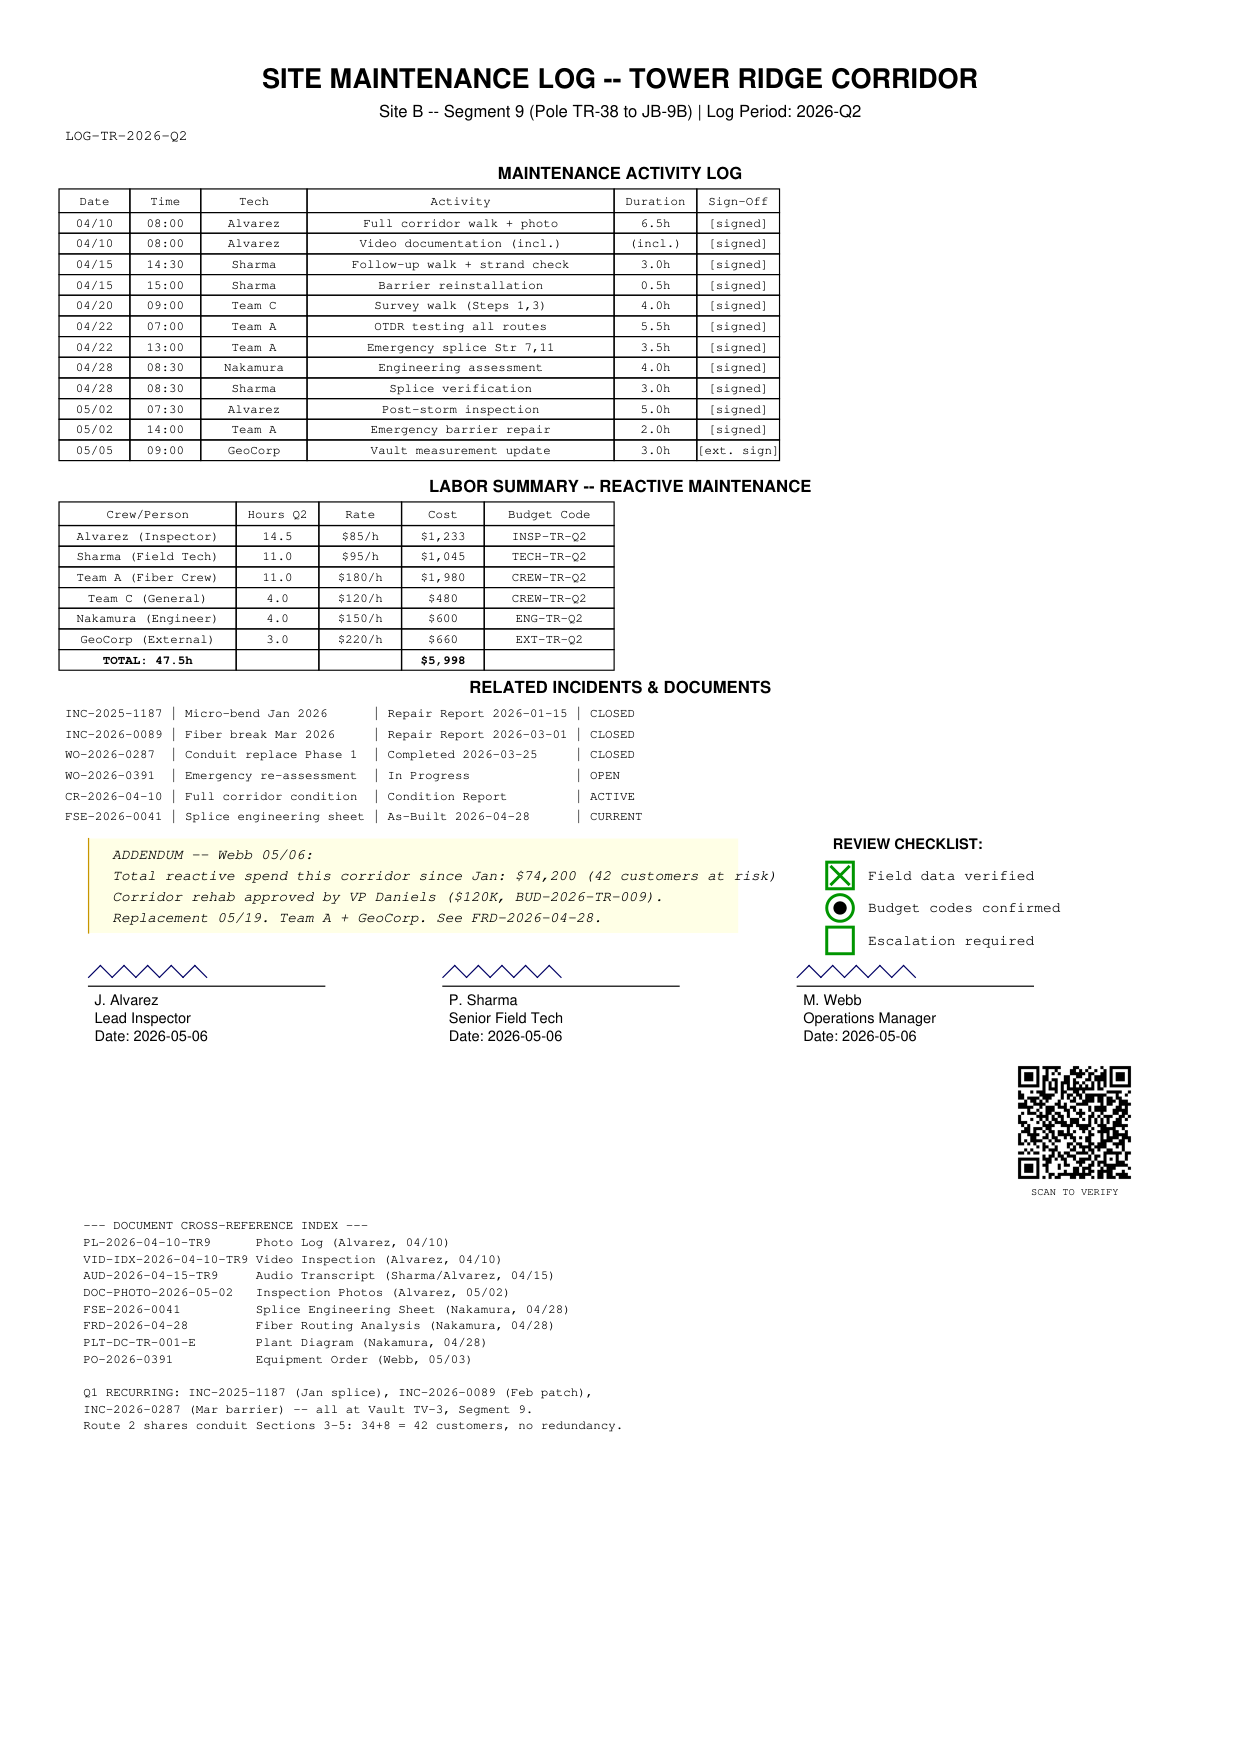

In [5]:
# Render the source document
maintenance_log = DOCS_DIR / "cl_v3_maintenance_log_2026_Q2.pdf"
display(Markdown("### Document: Site Maintenance Log — Q2 2026"))
show_pdf(maintenance_log)

### Approach 1: Local PDF Text Extraction (PyMuPDF)

Standard PDF library output — raw text with no structural awareness:
- **Tables become garbled text** — columns lose alignment, rows merge unpredictably
- **Selection marks (☑/☐) are lost** — the agent cannot determine approval status
- **No semantic sections** — headings, footers, and body text flatten into a single stream
- **Cross-page content breaks** — tables split mid-row with no continuation signal

In [52]:
# Local PDF library output — flat text, no structure
display(Markdown("### Local Extraction: PyMuPDF `page.get_text()`"))

doc = pymupdf.open(str(maintenance_log))
print(f"Pages: {len(doc)}")
print(f"{'═' * 70}")
print("RAW TEXT OUTPUT (first 2500 chars):")
print(f"{'═' * 70}\n")

raw_text = ""
for page_num in range(len(doc)):
    page = doc[page_num]
    raw_text += page.get_text()
doc.close()

# Show the raw text
print(raw_text[:2500])
print(f"\n{'─' * 70}")
print(f"Total raw text: {len(raw_text):,} chars")
print(f"\n⚠️  Limitations for agent consumption:")
print(f"   • Tables: columns lose alignment, rows merge unpredictably")
print(f"   • Selection marks (☑/☐): missing or rendered as Unicode debris")
print(f"   • Headers vs body: no distinction — flattened into a single stream")
print(f"   • An LLM parsing this would hallucinate table structure")

### Local Extraction: PyMuPDF `page.get_text()`

Pages: 1
══════════════════════════════════════════════════════════════════════
RAW TEXT OUTPUT (first 2500 chars):
══════════════════════════════════════════════════════════════════════

SITE MAINTENANCE LOG -- TOWER RIDGE CORRIDOR
Site B -- Segment 9 (Pole TR-38 to JB-9B) | Log Period: 2026-Q2
LOG-TR-2026-Q2
MAINTENANCE ACTIVITY LOG
Date
Time
Tech
Activity
Duration
Sign-Off
04/10
08:00
Alvarez
Full corridor walk + photo
6.5h
[signed]
04/10
08:00
Alvarez
Video documentation (incl.)
(incl.)
[signed]
04/15
14:30
Sharma
Follow-up walk + strand check
3.0h
[signed]
04/15
15:00
Sharma
Barrier reinstallation
0.5h
[signed]
04/20
09:00
Team C
Survey walk (Steps 1,3)
4.0h
[signed]
04/22
07:00
Team A
OTDR testing all routes
5.5h
[signed]
04/22
13:00
Team A
Emergency splice Str 7,11
3.5h
[signed]
04/28
08:30
Nakamura
Engineering assessment
4.0h
[signed]
04/28
08:30
Sharma
Splice verification
3.0h
[signed]
05/02
07:30
Alvarez
Post-storm inspection
5.0h
[signed]
05/02
14:00
Team A
Emergency barrier

### Approach 2: Azure Content Understanding

Same PDF, single API call. CU returns:
- **Proper Markdown tables** — rows and columns preserved, headers identified
- **Selection marks** as ☑/☐ — the agent can directly query approval status
- **Semantic headings** — document structure preserved (H1, H2, sections)
- **Cross-page table continuity** — tables that span pages are merged correctly
- **Figures with AI captions** — embedded images become searchable text
- **QR/barcode values** — decoded and returned as metadata

In [53]:
# Run CU extraction on the same document
maintenance_result = analyze_document(maintenance_log)
cu_markdown = maintenance_result.contents[0].markdown

# Side-by-side comparison: What the agent would receive from each approach
display(Markdown("### Head-to-Head: What Does the Agent Actually Get?"))

print(f"{'LOCAL PyMuPDF':<35} │ {'CONTENT UNDERSTANDING'}")
print(f"{'─' * 35}─┼─{'─' * 35}")
print(f"{'Flat text stream':<35} │ {'Markdown with | table | syntax'}")
print(f"{'No column alignment':<35} │ {'Columns preserved in pipe format'}")
print(f"{'Selection marks lost or garbled':<35} │ {'☑ and ☐ rendered correctly'}")
print(f"{'No heading hierarchy':<35} │ {'# H1, ## H2 structure intact'}")
print(f"{'Cross-page tables split':<35} │ {'Tables merged across pages'}")
print(f"{'Images = nothing':<35} │ {'Figures with AI-generated captions'}")
print(f"{'QR codes = invisible':<35} │ {'Decoded barcode/QR values'}")
print()

# Quantify the difference
content = maintenance_result.contents[0]
table_count = len(content.tables) if content.tables else 0
figure_count = len(content.figures) if content.figures else 0
barcode_count = sum(len(p.barcodes) for p in content.pages if p.barcodes) if content.pages else 0
checked = cu_markdown.count("☒")
unchecked = cu_markdown.count("☐")

print(f"CU structural elements extracted from this single PDF:")
print(f"   {table_count} tables (with row/column structure)")
print(f"   {figure_count} figures (with AI captions)")
print(f"   {barcode_count} barcodes/QR codes (decoded)")
print(f"   {checked} checked + {unchecked} unchecked selection marks")
print(f"\nPyMuPDF recovers none of these as structured data.")
print(f"An agent fed raw text would need to rely on perfect table boundaries")
print(f"and would miss other key elements like selection marks.")

### Head-to-Head: What Does the Agent Actually Get?

LOCAL PyMuPDF                       │ CONTENT UNDERSTANDING
────────────────────────────────────┼────────────────────────────────────
Flat text stream                    │ Markdown with | table | syntax
No column alignment                 │ Columns preserved in pipe format
Selection marks lost or garbled     │ ☑ and ☐ rendered correctly
No heading hierarchy                │ # H1, ## H2 structure intact
Cross-page tables split             │ Tables merged across pages
Images = nothing                    │ Figures with AI-generated captions
QR codes = invisible                │ Decoded barcode/QR values

CU structural elements extracted from this single PDF:
   2 tables (with row/column structure)
   0 figures (with AI captions)
   1 barcodes/QR codes (decoded)
   2 checked + 1 unchecked selection marks

PyMuPDF recovers none of these as structured data.
An agent fed raw text would need to rely on perfect table boundaries
and would miss other key elements like selection marks.


In [9]:
# CU structured elements — tables with full cell access
display(Markdown("### CU Structured Tables: Programmatic Access"))
show_extraction_summary(maintenance_result)

content = maintenance_result.contents[0]

# Show table structure — the agent can query these programmatically
print("\nTABLES EXTRACTED (agent gets row/col access, not text blobs):")
if content.tables:
    for i, table in enumerate(content.tables):
        print(f"\n  Table {i+1}: {table.row_count} rows × {table.column_count} cols")
        print(f"  {'─' * 55}")
        for cell in table.cells:
            if cell.row_index <= 2:
                print(f"    [{cell.row_index},{cell.column_index}] {cell.content[:50]}")
        if table.row_count > 3:
            print(f"    ... ({table.row_count - 3} more rows)")

### CU Structured Tables: Programmatic Access

**CU extracted:** **2 table(s)** • **158 paragraphs** • **1 barcode/QR** • **2☒ 1☐ selection marks**


TABLES EXTRACTED (agent gets row/col access, not text blobs):

  Table 1: 13 rows × 6 cols
  ───────────────────────────────────────────────────────
    [0,0] Date
    [0,1] Time
    [0,2] Tech
    [0,3] Activity
    [0,4] Duration
    [0,5] Sign-Off
    [1,0] 04/10
    [1,1] 08:00
    [1,2] Alvarez
    [1,3] Full corridor walk + photo
    [1,4] 6.5h
    [1,5] [signed]
    [2,0] 04/10
    [2,1] 08:00
    [2,2] Alvarez
    [2,3] Video documentation (incl.)
    [2,4] (incl.)
    [2,5] [signed]
    ... (10 more rows)

  Table 2: 8 rows × 5 cols
  ───────────────────────────────────────────────────────
    [0,0] Crew/Person
    [0,1] Hours Q2
    [0,2] Rate
    [0,3] Cost
    [0,4] Budget Code
    [1,0] Alvarez (Inspector)
    [1,1] 14.5
    [1,2] $85/h
    [1,3] $1,233
    [1,4] INSP-TR-Q2
    [2,0] Sharma (Field Tech)
    [2,1] 11.0
    [2,2] $95/h
    [2,3] $1,045
    [2,4] TECH-TR-Q2
    ... (5 more rows)


In [51]:
# AGENT DECISION POINT — Are we cleared to proceed?
display(Markdown("### Agent Reasoning: Check Approval Status"))
md = content.markdown

if "REVIEW CHECKLIST" in md:
    start = md.find("REVIEW CHECKLIST")
    end = md.find("\n\n", start + 80)
    print(md[start:end if end > 0 else start + 300])

print("\n" + "─" * 60)
reasoning = agent_reason(
    to_llm_input(maintenance_result),
    "Site Maintenance Log — Q2 2026 (tables, selection marks, cost data)",
    "Is this a new problem or a recurring one? Are we cleared to proceed with procurement?"
)
print("AGENT REASONING:")
print(reasoning)

### Agent Reasoning: Check Approval Status

REVIEW CHECKLIST:

☒
Field data verified

☒
Budget codes confirmed

☐
Escalation required

────────────────────────────────────────────────────────────
AGENT REASONING:
- The maintenance log lists multiple prior incidents in Segment 9: INC-2025-1187 (micro-bend, Jan 2026), INC-2026-0089 (fiber break, Mar 2026), and WO-2026-0287 (conduit replacement, Mar 2026), all at Vault TV-3, indicating recurring problems in this area.
- The addendum confirms total reactive spend since January is $74,200 for this corridor, showing ongoing costs and repeated interventions.
- Corridor rehabilitation has been formally approved by VP Daniels ($120K, BUD-2026-TR-009), and replacement work is scheduled for 05/19 with Team A and GeoCorp, confirming procurement clearance.
- The review checklist shows field data and budget codes are verified, with no escalation required, supporting readiness for procurement.
- Document cross-references and open work orders (WO-2026-0391) further indicate ongoing, unresolved 

The agent detects a recurring pattern. Next it needs field observations — the **audio transcript** from the April 15 site visit, recorded by a technician and inspector walking the corridor.

### Document: Field Audio Transcript (Apr 15)

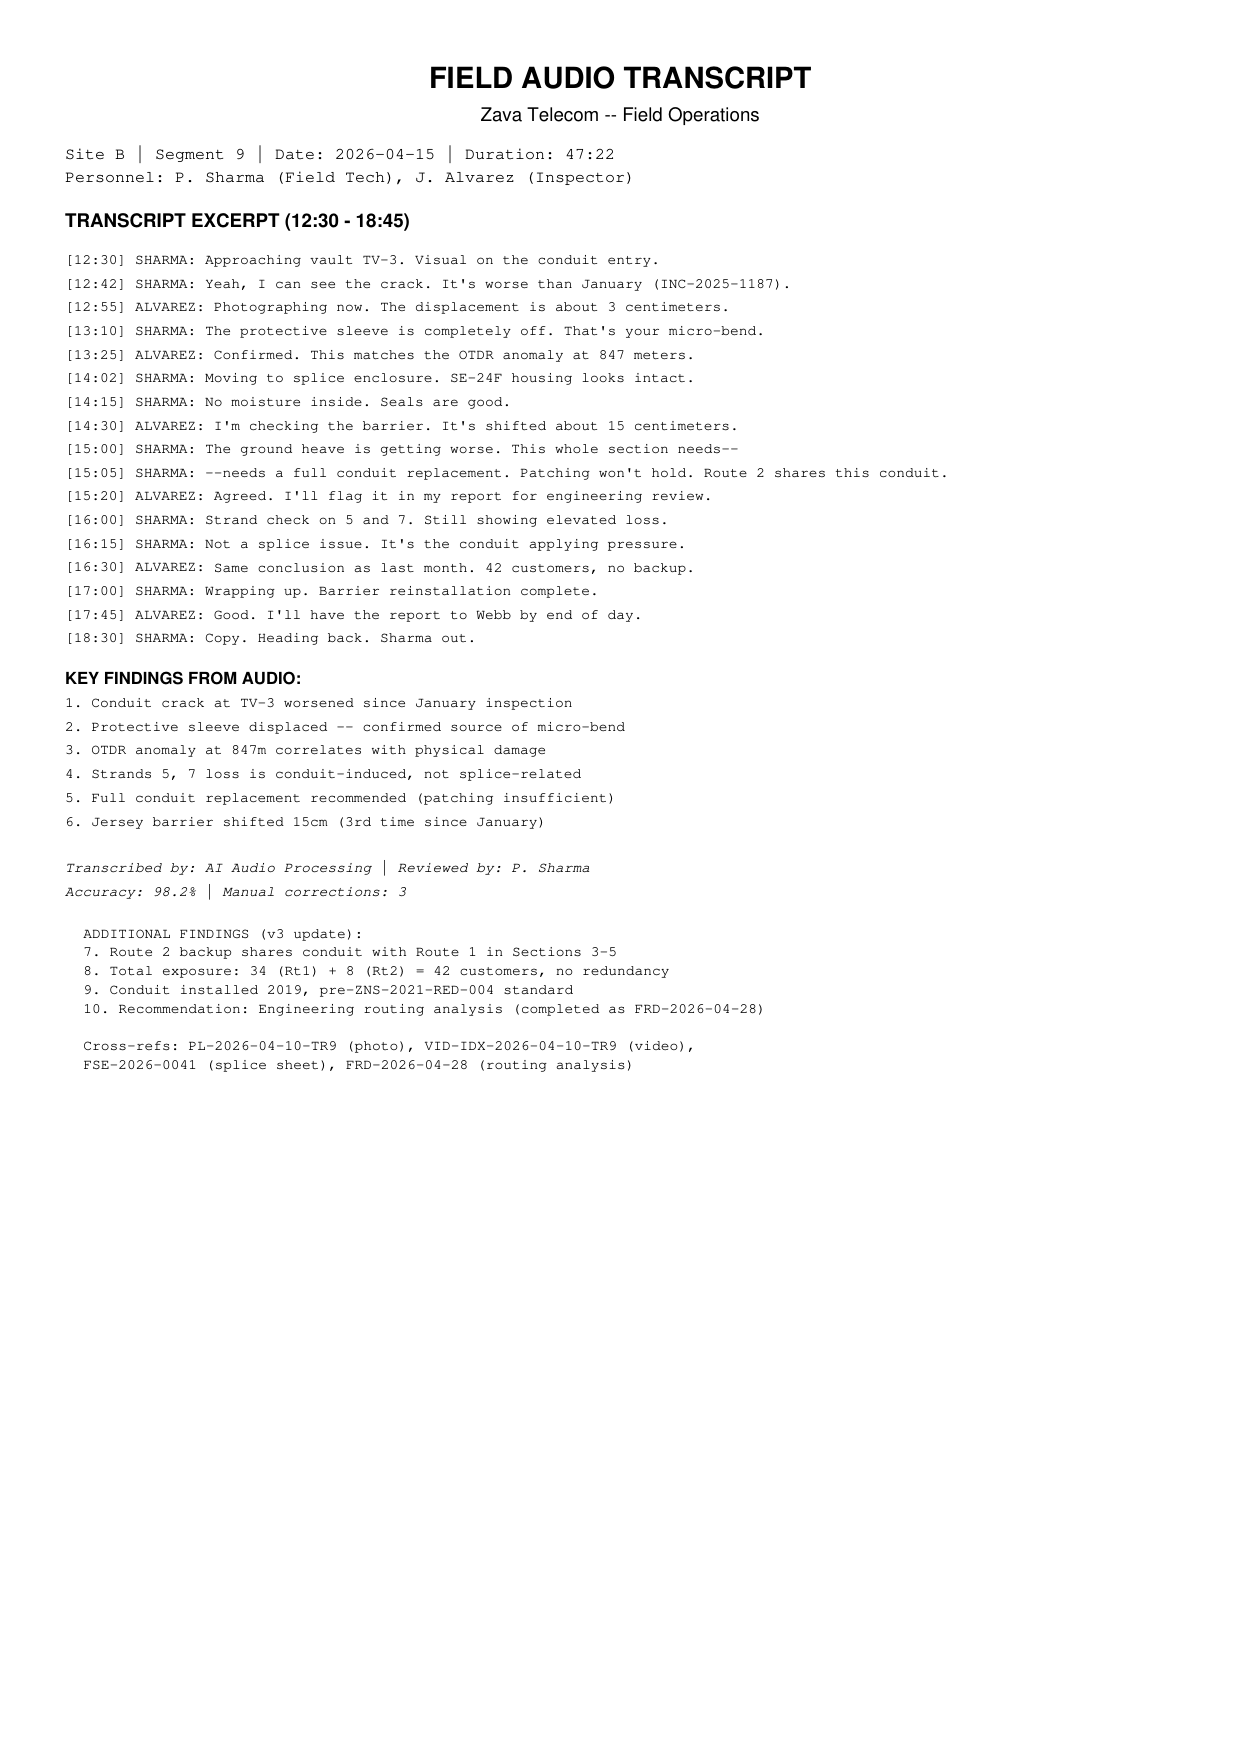

In [11]:
audio_transcript = DOCS_DIR / "cl_v3_site_b_audio_transcript_2026_04_15.pdf"
display(Markdown("### Document: Field Audio Transcript (Apr 15)"))
show_pdf(audio_transcript)

In [12]:
display(Markdown("### CU Extraction: Conversational Content"))
audio_result = analyze_document(audio_transcript)
show_extraction_summary(audio_result)

audio_md = audio_result.contents[0].markdown
print(audio_md[:1200])

print("\n" + "─" * 60)
reasoning = agent_reason(
    to_llm_input(audio_result),
    "Field Audio Transcript — technician and inspector walking the corridor (Apr 15)",
    "Does this corroborate the maintenance log findings? What's the field assessment?"
)
print("AGENT REASONING:")
print(reasoning)

### CU Extraction: Conversational Content

**CU extracted:** **36 paragraphs**

# FIELD AUDIO TRANSCRIPT Zava Telecom -- Field Operations

Site B | Segment 9 | Date: 2026-04-15 | Duration: 47:22

Personnel: P. Sharma (Field Tech), J. Alvarez (Inspector)


## TRANSCRIPT EXCERPT (12:30 - 18:45)

[12:30] SHARMA: Approaching vault TV-3. Visual on the conduit entry.

[12:42] SHARMA: Yeah, I can see the crack. It's worse than January (INC-2025-1187) .

[12:55] ALVAREZ: Photographing now. The displacement is about 3 centimeters.

[13:10] SHARMA: The protective sleeve is completely off. That's your micro-bend.

[13:25] ALVAREZ: Confirmed. This matches the OTDR anomaly at 847 meters.

[14:02] SHARMA: Moving to splice enclosure. SE-24F housing looks intact.

[14:15] SHARMA: No moisture inside. Seals are good.

[14:30] ALVAREZ: I'm checking the barrier. It's shifted about 15 centimeters.

[15:00] SHARMA: The ground heave is getting worse. This whole section needs--

[15:05] SHARMA: --needs a full conduit replacement. Patching won't hold. Route 2 shares this conduit.

[15:20]

---

## Act 2 — Show Me the Evidence

The agent has text-based evidence. Now it needs **visual confirmation**.

It retrieves **inspection photos** — a PDF with 6 embedded images, each GPS-tagged and timestamped. CU's figure extraction generates **AI captions** describing each image, making photos searchable and consumable by an LLM.

> **Key point:** The agent cannot process images directly — it reads CU's figure descriptions. A crack is not just pixels; it becomes `"3cm displacement"` with GPS coordinates.

### Document: Inspection Photos (May 2) — 6 embedded images

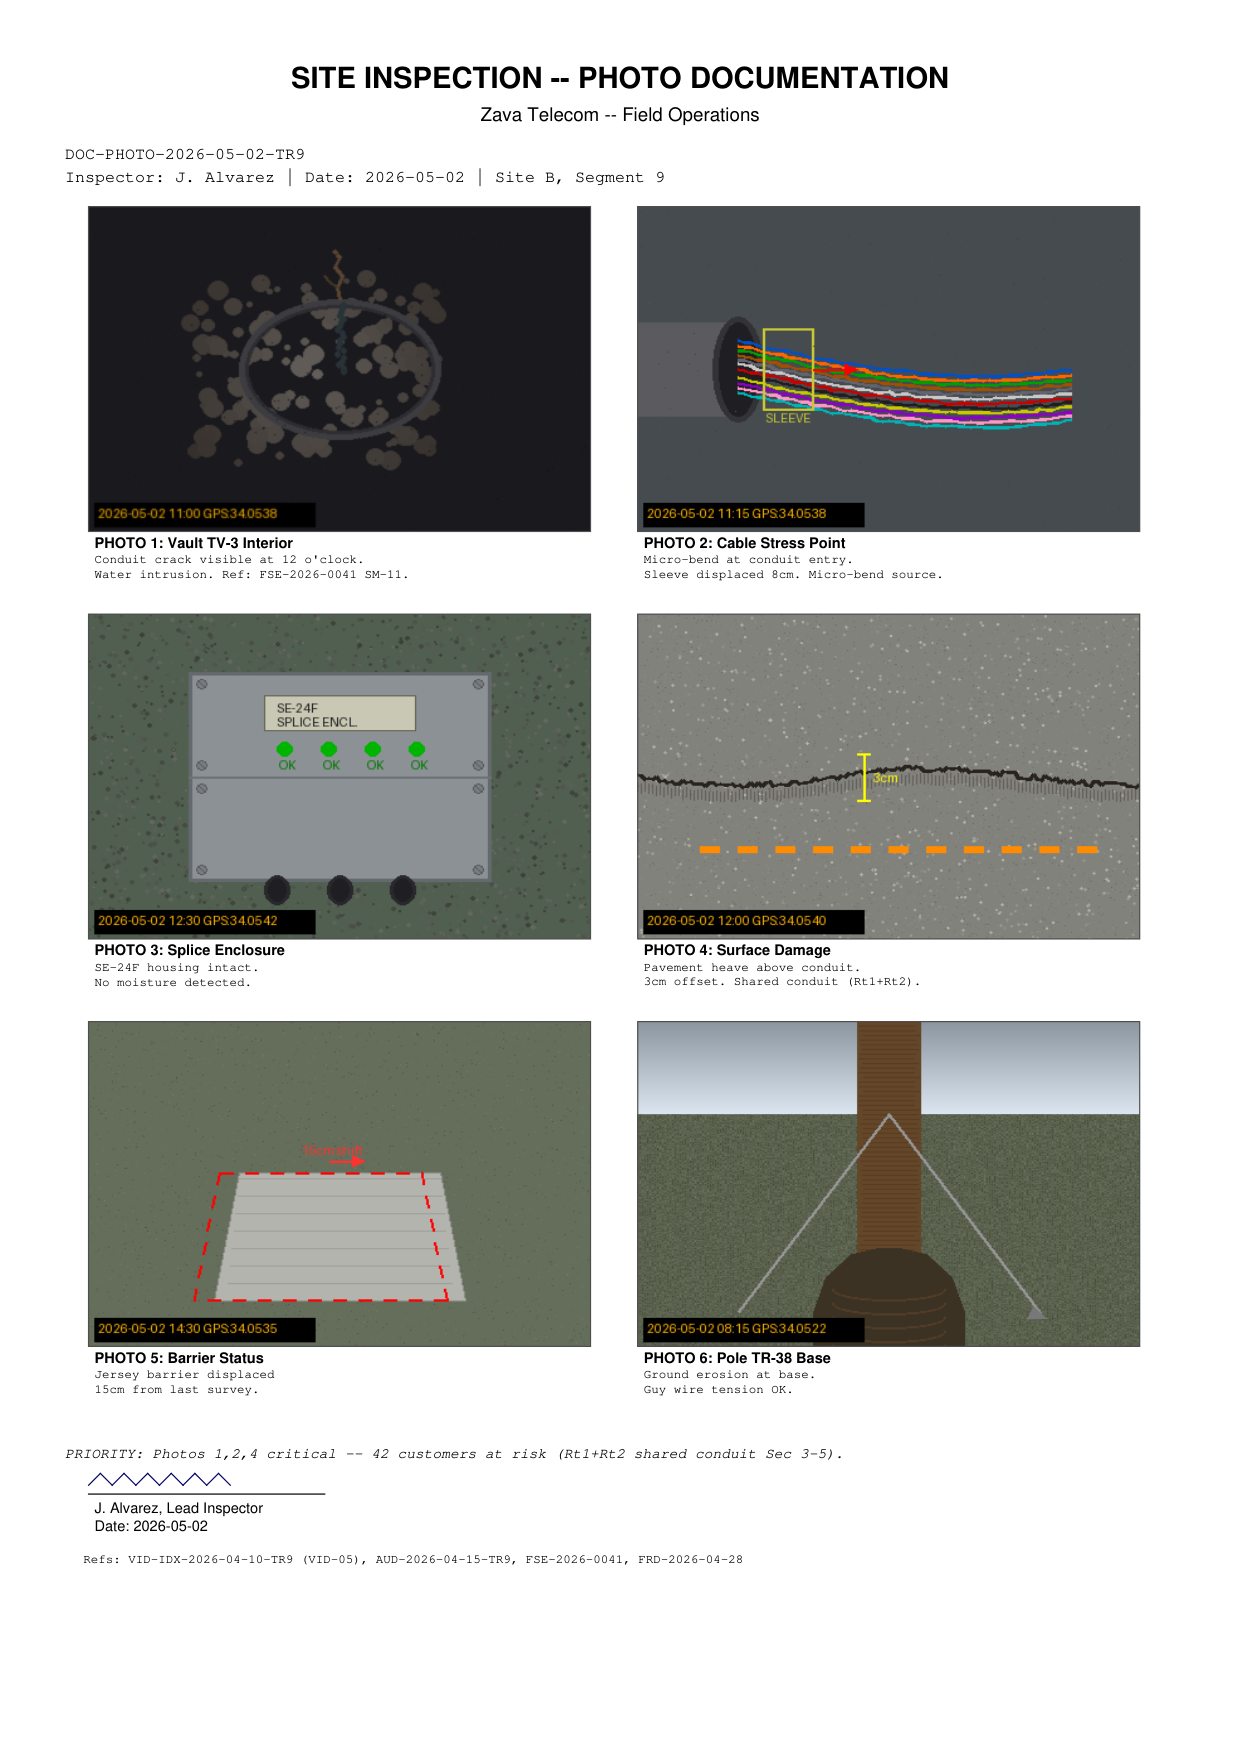

In [13]:
# THE DOCUMENT — 6 embedded field photos with GPS stamps
photos = DOCS_DIR / "cl_v3_inspection_photos_2026_05_02.pdf"
display(Markdown("### Document: Inspection Photos (May 2) — 6 embedded images"))
show_pdf(photos)

In [14]:
# CU generates figure descriptions — the agent can "see" through text
display(Markdown("### CU Extraction: Figures with AI-Generated Captions"))
photos_result = analyze_document(photos)
show_extraction_summary(photos_result)

photos_md = photos_result.contents[0].markdown
print(photos_md[:1800])

print("\n" + "─" * 60)
reasoning = agent_reason(
    to_llm_input(photos_result),
    "Inspection Photos (May 2) — 6 GPS-tagged field photos with AI captions",
    "Does visual evidence confirm the text-based findings? Is damage progressing?"
)
print("AGENT REASONING:")
print(reasoning)

### CU Extraction: Figures with AI-Generated Captions

**CU extracted:** **6 figure(s)** • **32 paragraphs**

# SITE INSPECTION -- PHOTO DOCUMENTATION Zava Telecom -- Field Operations

DOC-PHOTO-2026-05-02-TR9

Inspector: J. Alvarez | Date: 2026-05-02 | Site B, Segment 9


PHOTO 1: Vault TV-3 Interior

Conduit crack visible at 12 o'clock.
Water intrusion. Ref: FSE-2026-0041 SM-11.

![2026-05-02 11:00 GPS:34.0538](figures/1.1 "Circular vault interior with a gray circular ring near the center.
Multiple scattered circular spots of varying sizes in shades of brown and gray around and inside the ring.
A vertical crack or line at the top center (12 o'clock position) extending slightly inward from the ring.
A vertical wavy blue line inside the ring, slightly right of center.
Bottom left corner contains a black rectangular label with yellow text: "2026-05-02 11:00 GPS:34.0538".")


PHOTO 2: Cable Stress Point

![SLEEVE 2026-05-02 11:15 GPS:34.0538](figures/1.2 "Image of a cable with multiple colored strands extending from a dark circular conduit on the left.
Yellow rectangular box labeled 'SLEEVE' aro

---

## The Pivot: From Generic Extraction to Purpose-Built Agent Intelligence

Acts 1 and 2 used `prebuilt-documentSearch` — CU's general-purpose analyzer. It provided tables, figures, selection marks, and full markdown. Useful, but generic.

**The problem:** For the remaining 6 engineering documents, the agent needs *specific answers* to make decisions. Parsing free-text markdown wastes tokens and introduces interpretation errors.

**The solution: Custom analyzers.** Define the exact fields the agent needs — CU extracts them and, where specified, **reasons** about them.

| Document | Custom Analyzer | What the Agent Gets |
|----------|----------------|---------------------|
| Photo Log | `photoLogTriageAnalyzer` | Priority count, critical findings, **dispatch urgency recommendation** |
| Video Index | `videoInspectionAnalyzer` | Critical segments, escalation needed?, **damage trajectory** |
| Splice Sheet | `fiberSpliceExtractor` | Failed strands, failure mode, **engineering recommendation** |
| Fiber Routing | `fiberRoutingAnalyzer` | Redundancy gap, customer count, **single point of failure** |
| Equipment Spec | `equipmentProcurementAnalyzer` | Total cost, backorder risks, **budget verdict** |
| Plant Diagram | `plantDiagramAnalyzer` | Fiber entry point, thermal risk, **affected zone** |

> **Key point:** Fields like `DispatchUrgency` and `DamageProgression` do not exist in the source document — CU **infers** them from context. This is reasoning, not extraction.

In [15]:
# Define ALL custom analyzers for the remaining 6 documents

CUSTOM_ANALYZERS = {
    "photoLogTriageAnalyzer": {
        "description": "Triage field photo logs — extract priority findings and recommend dispatch urgency for the repair agent.",
        "baseAnalyzerId": "prebuilt-document",
        "scenario": "document",
        "models": {"completion": "gpt-4.1"},
        "fieldSchema": {"fields": {
            "HighPriorityCount": {
                "type": "integer", "method": "generate",
                "description": "Count of photos/entries marked HIGH priority."
            },
            "CriticalFindings": {
                "type": "string", "method": "generate",
                "description": "Summarize all HIGH-priority findings in one paragraph. Include location (GPS if available), subject, and why it's critical."
            },
            "DispatchUrgency": {
                "type": "string", "method": "generate",
                "description": "Based on the priority distribution and findings, classify overall dispatch urgency as: IMMEDIATE (>3 HIGH items or safety risk), URGENT (1-3 HIGH items), or SCHEDULED (no HIGH items). Explain your reasoning in one sentence."
            },
        }}
    },
    "videoInspectionAnalyzer": {
        "description": "Extract critical segments and escalation needs from video inspection indices for the repair agent.",
        "baseAnalyzerId": "prebuilt-document",
        "scenario": "document",
        "models": {"completion": "gpt-4.1"},
        "fieldSchema": {"fields": {
            "CriticalSegments": {
                "type": "string", "method": "generate",
                "description": "List video segments marked CRITICAL or 'Concern' with their timestamps and content. Format: 'VID-05 (52:30-78:00): Vault TV-3 CRITICAL damage; VID-06 (78:00-95:00): pavement heave'."
            },
            "EscalationRequired": {
                "type": "string", "method": "generate",
                "description": "YES or NO — is escalation to engineering required based on the video findings? Explain in one sentence."
            },
            "DamageProgression": {
                "type": "string", "method": "generate",
                "description": "Infer whether the damage is stable, worsening, or rapidly deteriorating based on segment descriptions, action items, and any temporal references. One sentence with evidence."
            },
        }}
    },
    "fiberSpliceExtractor": {
        "description": "Extract critical fiber splice data for the repair response agent.",
        "baseAnalyzerId": "prebuilt-document",
        "scenario": "document",
        "models": {"completion": "gpt-4.1"},
        "fieldSchema": {"fields": {
            "CableType": {
                "type": "string", "method": "generate",
                "description": "The fiber cable type/standard (e.g., 'G.652D Single-Mode', '12-strand SM OS2')."
            },
            "StrandCount": {
                "type": "integer", "method": "generate",
                "description": "Total number of fiber strands tested (exclude header row)."
            },
            "FailedStrands": {
                "type": "string", "method": "generate",
                "description": "List strands with MARGINAL or FAIL status: 'SM-5 (Slate, 0.52 dB/km, MARGINAL); SM-11 (Rose, 0.55 dB/km, FAIL)'. Include strand ID, color, loss, status."
            },
            "FailureMode": {
                "type": "string", "method": "generate",
                "description": "Root cause of degradation from engineering notes (e.g., 'micro-bend from conduit pressure')."
            },
            "MaxLoss": {
                "type": "number", "method": "generate",
                "description": "Highest loss value (dB/km) among all strands."
            },
            "EngineeringRecommendation": {
                "type": "string", "method": "generate",
                "description": "Engineer's recommendation: re-splice, conduit replacement, or other."
            },
        }}
    },
    "fiberRoutingAnalyzer": {
        "description": "Analyze fiber routing diagrams to identify redundancy gaps and single points of failure for the repair agent.",
        "baseAnalyzerId": "prebuilt-document",
        "scenario": "document",
        "models": {"completion": "gpt-4.1"},
        "fieldSchema": {"fields": {
            "RedundancyGap": {
                "type": "string", "method": "generate",
                "description": "Identify where primary and backup routes share infrastructure (conduit, vault, pole). Format: 'Route 2 shares conduit with Route 1 in Sections 3-5'. If none found, say 'No gap identified'."
            },
            "AffectedCustomers": {
                "type": "integer", "method": "generate",
                "description": "Number of customers at risk if the identified single point of failure is hit. Look for customer counts in route tables."
            },
            "SinglePointOfFailure": {
                "type": "string", "method": "generate",
                "description": "The specific infrastructure element that, if it fails, takes down BOTH primary and backup paths. Include location and what it is."
            },
            "RerouteOption": {
                "type": "string", "method": "generate",
                "description": "Infer if there's any alternative route available based on the network topology. If yes, describe it. If no, state 'No alternative — full conduit replacement required'."
            },
        }}
    },
    "equipmentProcurementAnalyzer": {
        "description": "Extract procurement-critical data from equipment specs and materials orders for budget/scheduling decisions.",
        "baseAnalyzerId": "prebuilt-document",
        "scenario": "document",
        "models": {"completion": "gpt-4.1"},
        "fieldSchema": {"fields": {
            "TotalCost": {
                "type": "number", "method": "generate",
                "description": "Total cost of all materials in the order (sum of line item totals). Return as a number without currency symbol."
            },
            "BackorderRisk": {
                "type": "string", "method": "generate",
                "description": "List any items that are backordered, out of stock, or have lead times >5 days. Format: 'Item (P/N): lead time or status'. If none, say 'All items available'."
            },
            "CriticalPathDays": {
                "type": "integer", "method": "generate",
                "description": "The longest lead time (in days) among all items — this determines earliest possible start date for the repair."
            },
            "BudgetVerdict": {
                "type": "string", "method": "generate",
                "description": "Compare total cost against any mentioned approved budget. State: 'WITHIN BUDGET ($X of $Y)' or 'OVER BUDGET ($X of $Y)'. If no budget mentioned, state 'No budget reference found'."
            },
        }}
    },
    "plantDiagramAnalyzer": {
        "description": "Analyze data center plant diagrams to identify affected zones, thermal risks, and fiber connectivity for repair planning.",
        "baseAnalyzerId": "prebuilt-document",
        "scenario": "document",
        "models": {"completion": "gpt-4.1"},
        "fieldSchema": {"fields": {
            "FiberEntryPoint": {
                "type": "string", "method": "generate",
                "description": "Where external fiber enters the facility. Look for ODF, MDF, fiber tray, or demarc labels."
            },
            "ThermalRisk": {
                "type": "string", "method": "generate",
                "description": "Any thermal or cooling concerns mentioned (hot spots, CRAC issues, blocked airflow). If none, say 'No thermal issues noted'."
            },
            "AffectedZone": {
                "type": "string", "method": "generate",
                "description": "Which racks, rows, or zones would be affected by the fiber issue being investigated. Look for highlighted areas, field notes, or damage annotations."
            },
            "FieldNotes": {
                "type": "string", "method": "generate",
                "description": "Any handwritten or appended field notes, engineer annotations, or approval stamps with dates."
            },
        }}
    },
}

display(Markdown("### Custom Analyzer Definitions"))
print(f"Defined {len(CUSTOM_ANALYZERS)} custom analyzers:\n")
for name, schema in CUSTOM_ANALYZERS.items():
    fields = list(schema["fieldSchema"]["fields"].keys())
    print(f"  {name}")
    print(f"    Fields: {', '.join(fields)}\n")


### Custom Analyzer Definitions

Defined 6 custom analyzers:

  photoLogTriageAnalyzer
    Fields: HighPriorityCount, CriticalFindings, DispatchUrgency

  videoInspectionAnalyzer
    Fields: CriticalSegments, EscalationRequired, DamageProgression

  fiberSpliceExtractor
    Fields: CableType, StrandCount, FailedStrands, FailureMode, MaxLoss, EngineeringRecommendation

  fiberRoutingAnalyzer
    Fields: RedundancyGap, AffectedCustomers, SinglePointOfFailure, RerouteOption

  equipmentProcurementAnalyzer
    Fields: TotalCost, BackorderRisk, CriticalPathDays, BudgetVerdict

  plantDiagramAnalyzer
    Fields: FiberEntryPoint, ThermalRisk, AffectedZone, FieldNotes



In [17]:
# Deploy all custom analyzers (batch)
from azure.ai.contentunderstanding.models import (
    ContentAnalyzer,
    ContentFieldSchema,
    ContentFieldDefinition,
    ContentFieldType,
    GenerationMethod,
)

display(Markdown("### Deploying All Custom Analyzers"))

# Map raw type strings to SDK enums
_TYPE_MAP = {
    "string": ContentFieldType.STRING,
    "integer": ContentFieldType.INTEGER,
    "number": ContentFieldType.NUMBER,
}

def deploy_analyzer(analyzer_id, schema):
    """Deploy a single custom analyzer using the SDK."""
    # Build field schema from the definition
    fields = {
        name: ContentFieldDefinition(
            type=_TYPE_MAP[fdef["type"]],
            method=GenerationMethod.GENERATE,
            description=fdef["description"],
        )
        for name, fdef in schema["fieldSchema"]["fields"].items()
    }
    field_schema = ContentFieldSchema(fields=fields)

    # Create the analyzer resource
    analyzer = ContentAnalyzer(
        base_analyzer_id=schema["baseAnalyzerId"],
        description=schema["description"],
        field_schema=field_schema,
        models=schema["models"],
    )

    try:
        poller = client.begin_create_analyzer(
            analyzer_id=analyzer_id, resource=analyzer, allow_replace=True
        )
        result = poller.result()
        return "✅ ready"
    except Exception as e:
        return f"❌ {e}"

print(f"{'Analyzer':<32} {'Status':<12}")
print(f"{'-'*32} {'-'*12}")
for name, schema in CUSTOM_ANALYZERS.items():
    status = deploy_analyzer(name, schema)
    print(f"{name:<32} {status}")

print(f"\n✅ All analyzers deployed — agent is ready for deep extraction.")

### Deploying All Custom Analyzers

Analyzer                         Status      
-------------------------------- ------------
photoLogTriageAnalyzer           ✅ ready
videoInspectionAnalyzer          ✅ ready
fiberSpliceExtractor             ✅ ready
fiberRoutingAnalyzer             ✅ ready
equipmentProcurementAnalyzer     ✅ ready
plantDiagramAnalyzer             ✅ ready

✅ All analyzers deployed — agent is ready for deep extraction.


---

### Production Pattern: Classify → Route → Extract (Single API Call)

In production, the agent does not hardcode which analyzer to use. A **classifier** inspects each incoming document and routes it to the appropriate analyzer automatically:

```
  Unknown PDF ──▶ Classifier ──▶ "Splice_Sheet" ──▶ fiberSpliceExtractor ──▶ {FailedStrands, MaxLoss, ...}
```

A single call handles both classification and extraction. The agent receives typed fields — no document-type branching in application code.

In [18]:
# Create a classifier that routes documents to the deployed custom analyzers
from azure.ai.contentunderstanding.models import (
    ContentAnalyzer,
    ContentAnalyzerConfig,
    ContentCategoryDefinition,
)

CLASSIFIER_ID = "fiberFieldDocClassifier"

# Define categories — each maps to a deployed custom analyzer
categories = {
    "Photo_Log": ContentCategoryDefinition(
        description="GPS-indexed photo logs from field inspections with priority ratings "
        "(HIGH/MEDIUM/LOW) for each photo entry, documenting site conditions and damage.",
        analyzer_id="photoLogTriageAnalyzer",
    ),
    # Note: classifier requires document input. CU can analyze video files directly with the video analyzer; here we route based on document content.
    "Video_Inspection": ContentCategoryDefinition(
        description="Video inspection index documents listing numbered video segments "
        "with timestamps, locations, damage classifications, and action items.",
        analyzer_id="videoInspectionAnalyzer",
    ),
    "Splice_Sheet": ContentCategoryDefinition(
        description="Engineering fiber splice sheets with strand-level OTDR loss measurements, "
        "color codes, pass/fail status, and technician notes about failure modes.",
        analyzer_id="fiberSpliceExtractor",
    ),
    "Fiber_Routing": ContentCategoryDefinition(
        description="Network fiber routing diagrams showing primary and backup paths, "
        "conduit sections, customer counts per route, and redundancy information.",
        analyzer_id="fiberRoutingAnalyzer",
    ),
    "Equipment_Spec": ContentCategoryDefinition(
        description="Equipment specification and materials order documents with part numbers, "
        "quantities, costs, lead times, and procurement status.",
        analyzer_id="equipmentProcurementAnalyzer",
    ),
    "Plant_Diagram": ContentCategoryDefinition(
        description="Data center or facility plant diagrams showing rack layouts, "
        "fiber paths, cooling systems, and field annotations.",
        analyzer_id="plantDiagramAnalyzer",
    ),
}

# Classifier configuration
config = ContentAnalyzerConfig(
    return_details=True,
    enable_segment=False,  # Single-doc classification (not splitting multi-doc PDFs)
    content_categories=categories,
)

# Create the classifier analyzer resource
classifier = ContentAnalyzer(
    base_analyzer_id="prebuilt-document",
    description="Classifies field service documents and routes to the correct custom analyzer",
    config=config,
    models={"completion": "gpt-4.1"},
)

# Deploy the classifier
display(Markdown("### Creating Document Classifier"))
print(f"Deploying classifier: {CLASSIFIER_ID}")
print(f"Categories: {', '.join(categories.keys())}")
print(f"Each category routes to its custom analyzer for field extraction.\n")

poller = client.begin_create_analyzer(analyzer_id=CLASSIFIER_ID, resource=classifier, allow_replace=True)
result = poller.result()

print(f"✅ Classifier '{CLASSIFIER_ID}' deployed!")
print(f"   Description: {result.description}")
print(f"   Categories: {len(categories)}")

### Creating Document Classifier

Deploying classifier: fiberFieldDocClassifier
Categories: Photo_Log, Video_Inspection, Splice_Sheet, Fiber_Routing, Equipment_Spec, Plant_Diagram
Each category routes to its custom analyzer for field extraction.

✅ Classifier 'fiberFieldDocClassifier' deployed!
   Description: Classifies field service documents and routes to the correct custom analyzer
   Categories: 6


In [19]:
# Classify and route a document without specifying the analyzer
from typing import cast

display(Markdown("### Classifier in Action: Route an Unknown Document"))
print("The agent receives a document without knowing its type.")
print("The classifier identifies the category and extracts fields in a single call.\n")

# Send the splice sheet through the classifier (type unknown to the agent)
test_doc = DOCS_DIR / "cl_v3_engineering_splice_sheet_2026_04_28.pdf"
print(f"Document: {test_doc.name}")
print(f"Sending to classifier '{CLASSIFIER_ID}'...\n")

with open(test_doc, "rb") as f:
    classify_poller = client.begin_analyze_binary(
        analyzer_id=CLASSIFIER_ID, binary_input=f.read()
    )
classify_result = classify_poller.result()

# Show classification + routed extraction results
doc_content = cast(DocumentContent, classify_result.contents[0])

if doc_content.segments and len(doc_content.segments) > 0:
    for segment in doc_content.segments:
        print(f"  Category: {segment.category}")
        print(f"     Pages: {segment.start_page_number}-{segment.end_page_number}")

# Show fields extracted by the routed analyzer (on the content level)
if doc_content.fields:
    print(f"\n  Routed to custom analyzer — extracted fields:")
    for fname, fval in doc_content.fields.items():
        v = fval.value if fval.value is not None else fval.value_string
        print(f"     {fname}: {v}")

# Show to_llm_input — it auto-detects classification and formats per-segment
print("\n" + "─" * 60)
print("to_llm_input() auto-formats classification results:\n")
classify_text = to_llm_input(classify_result, include_markdown=False)
print(classify_text[:1200])

print("\n" + "─" * 60)
print("Document automatically classified, routed, and extracted.")
print("   No manual analyzer selection required.")

### Classifier in Action: Route an Unknown Document

The agent receives a document and doesn't know which type it is.
The classifier identifies the category AND extracts fields in one call.

Document: cl_v3_engineering_splice_sheet_2026_04_28.pdf
Sending to classifier 'fiberFieldDocClassifier'...

  Category: Splice_Sheet
     Pages: 1-1

────────────────────────────────────────────────────────────
to_llm_input() auto-formats classification results:

---
contentType: document
category: Splice_Sheet
pages: 1
fields:
  CableType: 12-SM OS2 Tight
  StrandCount: 12
  FailedStrands: SM-5 (Slate, 0.52 dB/km, MARGINAL); SM-7 (Red, 0.48 dB/km, MARGINAL); SM-11 (Rose, 0.55 dB/km, FAIL)
  FailureMode: Conduit is root cause.
  MaxLoss: 0.55
  EngineeringRecommendation: Aerial bypass for Route 2 BEFORE conduit replacement.
rai_warnings:
- code: LLMStats
  message: 'completion calls: 3; completion latency: 7.99s'
---

────────────────────────────────────────────────────────────
AGENT: Document automatically classified → routed → extracted.
   No manu

In [20]:
# Route ALL 6 documents through the classifier — show it correctly identifies each
display(Markdown("### Batch Classification: All 6 Documents"))
print("Sending all 6 field documents through the classifier...\n")

test_docs = [
    ("cl_v3_site_b_photo_log_2026_04_10.pdf", "Photo_Log"),
    ("cl_v3_site_b_video_inspection_2026_04_10.pdf", "Video_Inspection"),
    ("cl_v3_engineering_splice_sheet_2026_04_28.pdf", "Splice_Sheet"),
    ("cl_v3_datacenter_fiber_routing_2026_04_28.pdf", "Fiber_Routing"),
    ("cl_v3_equipment_spec_sheet_2026_05_03.pdf", "Equipment_Spec"),
    ("cl_v3_datacenter_plant_diagram_2026_04_28.pdf", "Plant_Diagram"),
]

print(f"{'Document':<50} {'Classified As':<20} {'Correct?'}")
print(f"{'-'*50} {'-'*20} {'-'*8}")

for filename, expected in test_docs:
    doc_path = DOCS_DIR / filename
    with open(doc_path, "rb") as f:
        p = client.begin_analyze_binary(analyzer_id=CLASSIFIER_ID, binary_input=f.read())
    r = p.result()
    dc = cast(DocumentContent, r.contents[0])
    
    # Get the classified category
    classified = "(unknown)"
    if dc.segments and len(dc.segments) > 0:
        classified = dc.segments[0].category or "(unknown)"
    
    correct = "✅" if classified == expected else "❌"
    print(f"{filename:<50} {classified:<20} {correct}")

print(f"\n✅ Classifier correctly identifies all document types.")
print("   In production, a single endpoint call handles classification and extraction.")


### Batch Classification: All 6 Documents

Sending all 6 field documents through the classifier...

Document                                           Classified As        Correct?
-------------------------------------------------- -------------------- --------
cl_v3_site_b_photo_log_2026_04_10.pdf              Photo_Log            ✅
cl_v3_site_b_video_inspection_2026_04_10.pdf       Video_Inspection     ✅
cl_v3_engineering_splice_sheet_2026_04_28.pdf      Splice_Sheet         ✅
cl_v3_datacenter_fiber_routing_2026_04_28.pdf      Fiber_Routing        ✅
cl_v3_equipment_spec_sheet_2026_05_03.pdf          Equipment_Spec       ✅
cl_v3_datacenter_plant_diagram_2026_04_28.pdf      Plant_Diagram        ✅

✅ Classifier correctly identifies all document types.
   In production: agent calls ONE endpoint, CU handles classification + extraction.


---

## Act 3 — Deep Extraction: The Agent Builds Its Case

With custom analyzers deployed, the agent processes 6 specialized engineering documents. Each returns **structured fields** consumed directly by the agent's decision logic — no markdown parsing, no prompt engineering.

**Pattern for each:** Render the PDF → Show custom analyzer output → Agent reasoning

### Photo Log — GPS-indexed with priority ratings

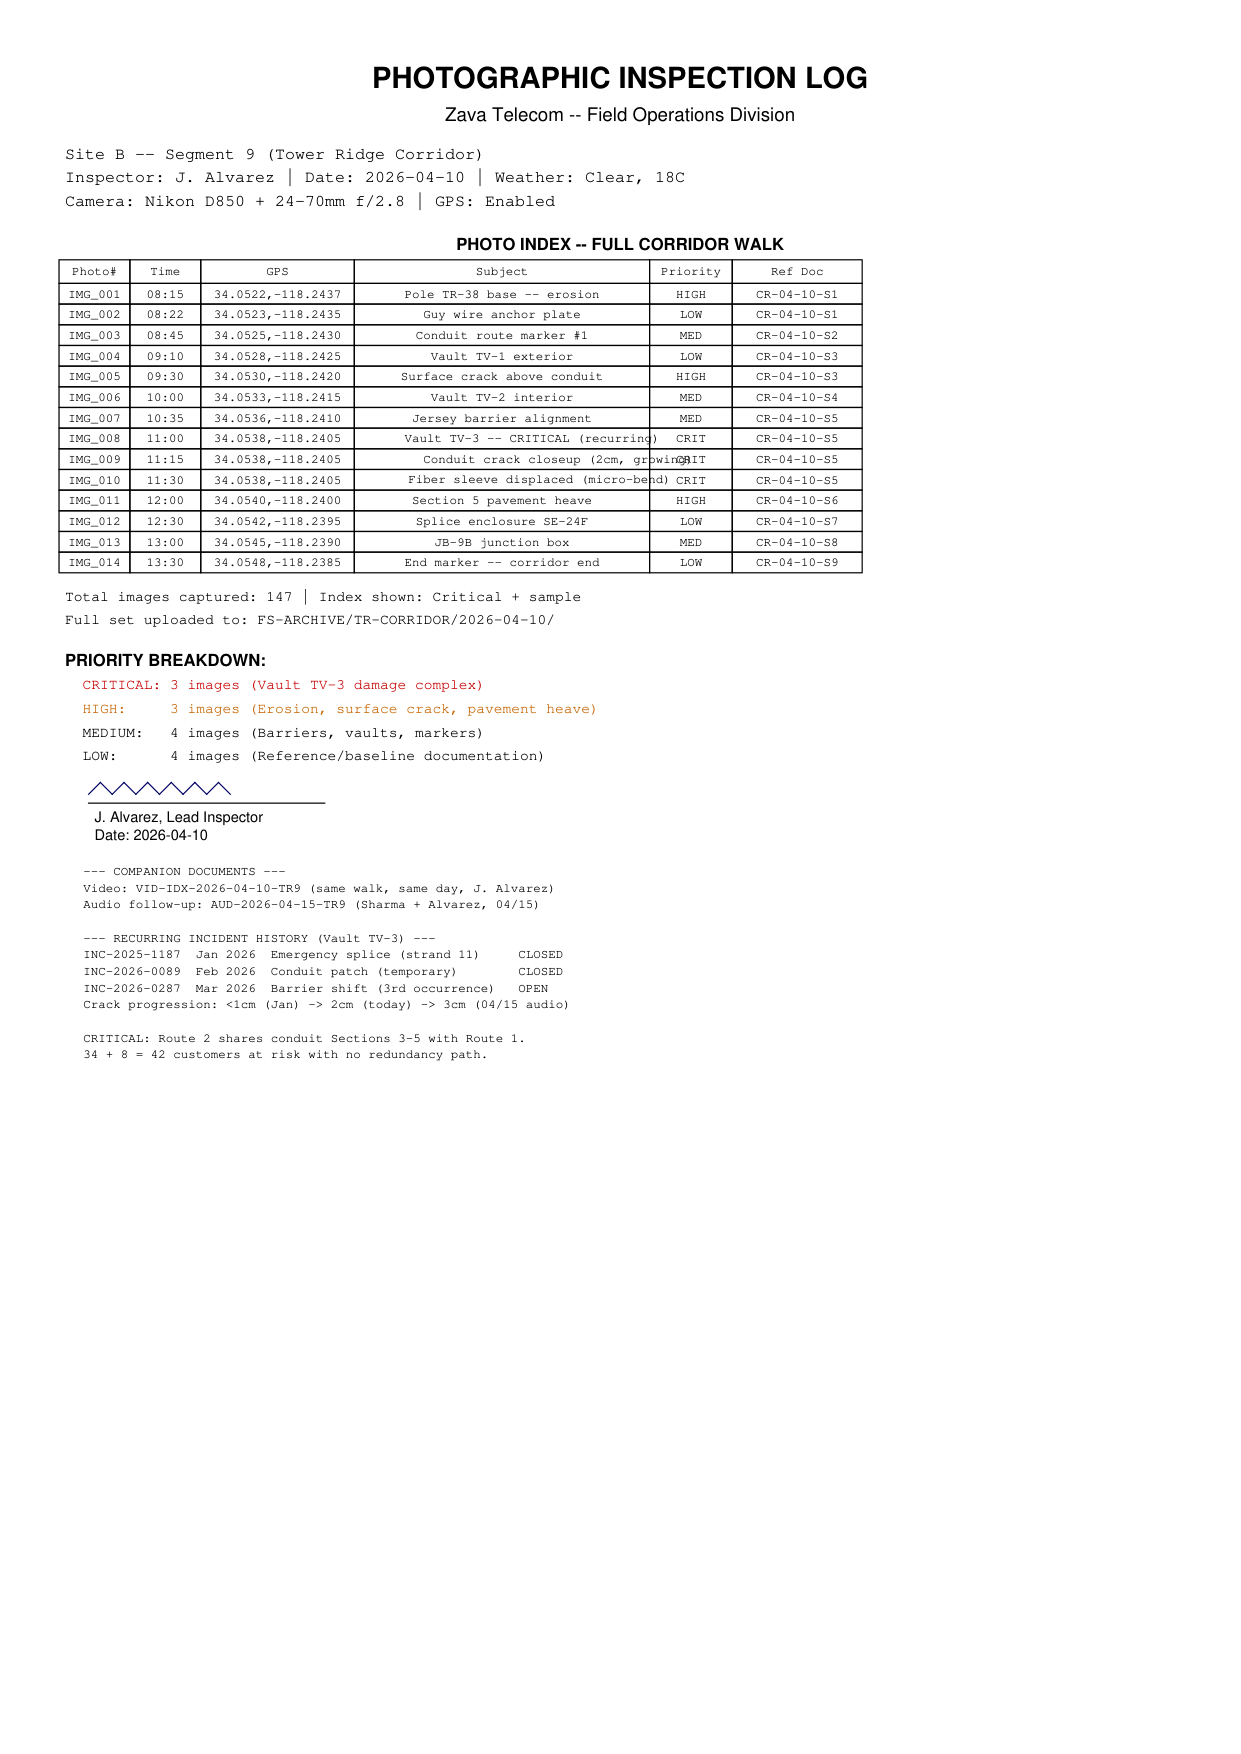

In [21]:
# Photo Log — with custom analyzer
photo_log = DOCS_DIR / "cl_v3_site_b_photo_log_2026_04_10.pdf"
display(Markdown("### Photo Log — GPS-indexed with priority ratings"))
show_pdf(photo_log)


In [22]:
# Custom extraction: photoLogTriageAnalyzer
display(Markdown("### Custom Extraction: `photoLogTriageAnalyzer`"))

with open(photo_log, "rb") as f:
    photo_log_poller = client.begin_analyze_binary(
        analyzer_id="photoLogTriageAnalyzer", binary_input=f.read()
    )
photo_log_result = photo_log_poller.result()

pl_fields = photo_log_result.contents[0].fields
if pl_fields:
    for name, val in pl_fields.items():
        v = val.value if val.value is not None else val.value_string
        print(f"  {name}: {v}")

print("\n" + "─" * 60)
reasoning = agent_reason(
    to_llm_input(photo_log_result, include_markdown=False),
    "Photo Log — GPS-indexed field photos with priority ratings",
    "What's the triage assessment? How urgent is dispatch?"
)
print("AGENT [1/6]:")
print(reasoning)

### Custom Extraction: `photoLogTriageAnalyzer`

  HighPriorityCount: 3
  CriticalFindings: Three HIGH-priority findings: (1) Pole TR-38 base erosion at GPS 34.0522,-118.2437, (2) Surface crack above conduit at GPS 34.0530,-118.2420, and (3) Section 5 pavement heave at GPS 34.0540,-118.2400. These are critical due to structural risks to the corridor, potential conduit failure, and possible service disruption.
  DispatchUrgency: URGENT (1-3 HIGH items). There are 3 HIGH-priority findings, which require prompt attention but do not exceed the threshold for IMMEDIATE dispatch.

────────────────────────────────────────────────────────────
AGENT [1/6]:
- The photo log identifies 3 HIGH-priority findings: pole base erosion, surface crack above conduit, and pavement heave, all posing structural and conduit risks.
- GPS coordinates confirm these issues are distributed along the Tower Ridge Corridor, directly affecting Segment 9 and potentially impacting 42 customers.
- The triage assessment rates dispatch urgency as URGENT, indicating prompt 

### Video Inspection Index — 6 segments with damage classification

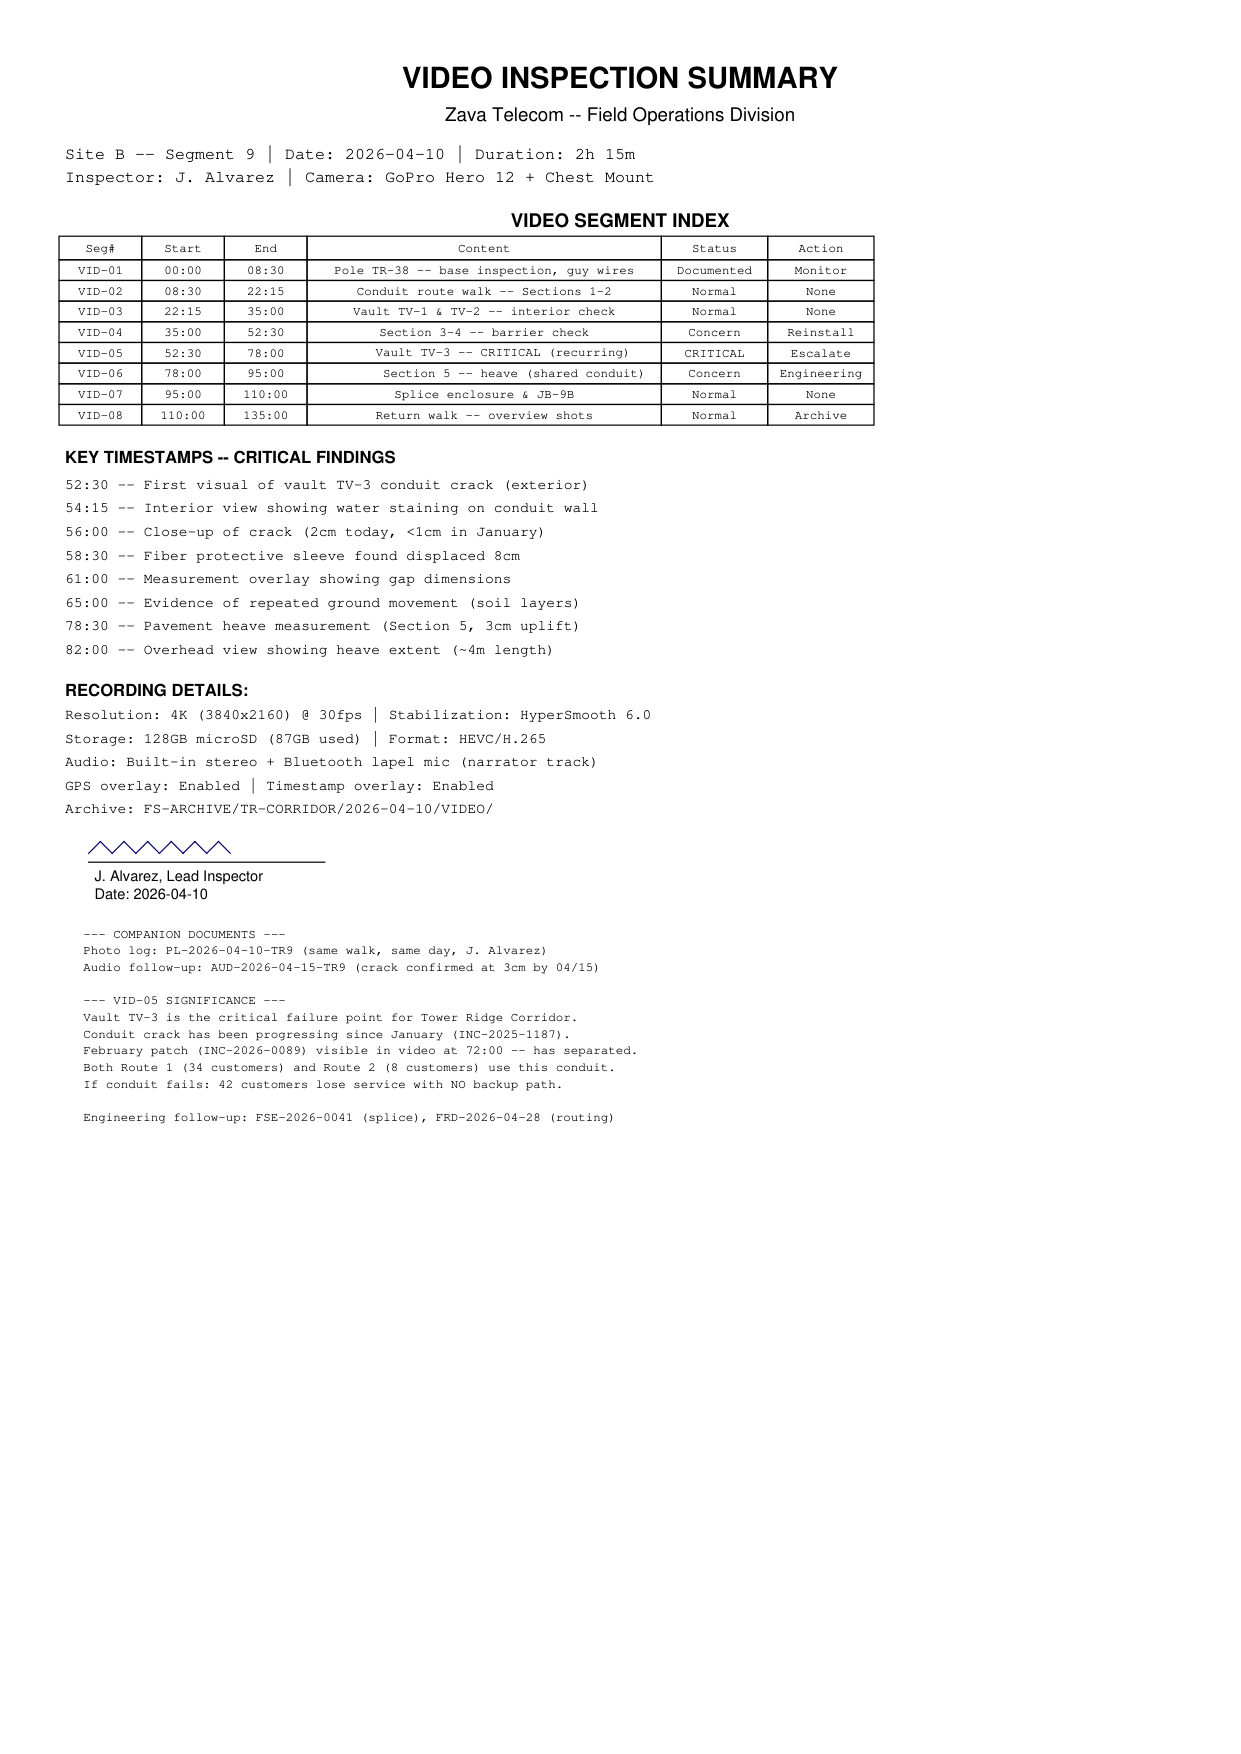

In [23]:
# Video Inspection Index — with custom analyzer
video_inspection = DOCS_DIR / "cl_v3_site_b_video_inspection_2026_04_10.pdf"
display(Markdown("### Video Inspection Index — 6 segments with damage classification"))
show_pdf(video_inspection)

In [24]:
# Custom extraction: videoInspectionAnalyzer
display(Markdown("### Custom Extraction: `videoInspectionAnalyzer`"))

with open(video_inspection, "rb") as f:
    video_poller = client.begin_analyze_binary(
        analyzer_id="videoInspectionAnalyzer", binary_input=f.read()
    )
video_result = video_poller.result()

vi_fields = video_result.contents[0].fields
if vi_fields:
    for name, val in vi_fields.items():
        v = val.value if val.value is not None else val.value_string
        print(f"  {name}: {v}")

print("\n" + "─" * 60)
reasoning = agent_reason(
    to_llm_input(video_result, include_markdown=False),
    "Video Inspection Index — 6 segments with damage classification",
    "Does video confirm photo evidence? Is damage stable or worsening?"
)
print("AGENT [2/6]:")
print(reasoning)

### Custom Extraction: `videoInspectionAnalyzer`

  CriticalSegments: VID-05 (52:30-78:00): Vault TV-3 -- CRITICAL (recurring); VID-06 (78:00-95:00): Section 5 -- heave (shared conduit)
  EscalationRequired: YES. Escalation to engineering is required due to the recurring and worsening crack in Vault TV-3 and pavement heave in Section 5, both of which threaten service continuity.
  DamageProgression: The damage is worsening, as evidenced by the Vault TV-3 conduit crack increasing from less than 1cm in January to 2cm in April, patch separation, and new ground movement and pavement heave observed.

────────────────────────────────────────────────────────────
AGENT [2/6]:
- Video inspection confirms photo evidence, showing recurring and worsening damage in Vault TV-3 (crack increased from <1cm in January to 2cm in April).
- Section 5 exhibits new ground movement and pavement heave, matching prior photo documentation and indicating shared conduit risk.
- Patch separation and escalation to engineering are recommended due to the threat to se

### Fiber Splice Sheet — strand-level loss measurements

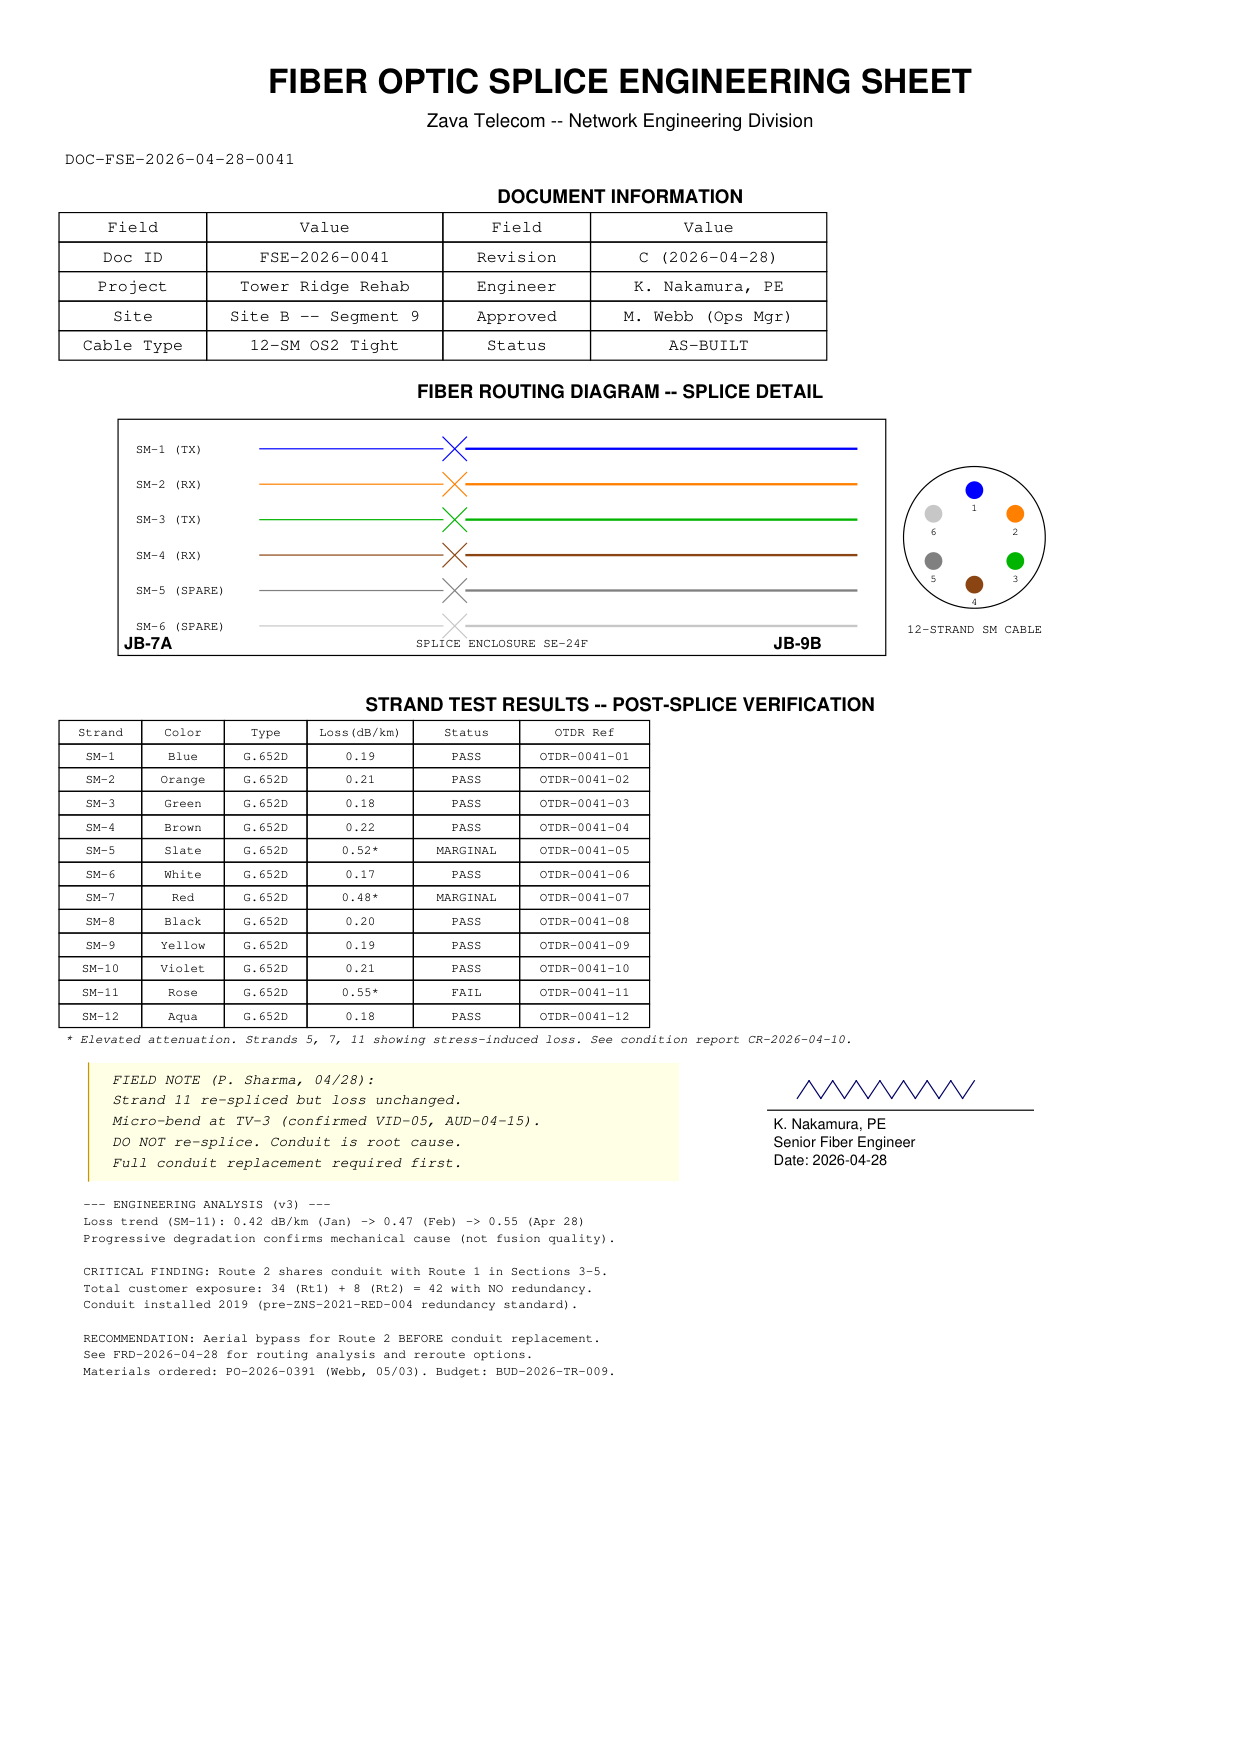

In [25]:
# Splice Sheet — with custom analyzer (already deployed)
splice_sheet = DOCS_DIR / "cl_v3_engineering_splice_sheet_2026_04_28.pdf"
display(Markdown("### Fiber Splice Sheet — strand-level loss measurements"))
show_pdf(splice_sheet)

In [26]:
# Custom extraction: fiberSpliceExtractor
display(Markdown("### Custom Extraction: `fiberSpliceExtractor`"))

with open(splice_sheet, "rb") as f:
    splice_poller = client.begin_analyze_binary(
        analyzer_id="fiberSpliceExtractor", binary_input=f.read()
    )
splice_result = splice_poller.result()

sp_fields = splice_result.contents[0].fields
if sp_fields:
    for name, val in sp_fields.items():
        v = val.value if val.value is not None else val.value_string
        print(f"  {name}: {v}")

print("\n" + "─" * 60)
reasoning = agent_reason(
    to_llm_input(splice_result, include_markdown=False),
    "Engineering Splice Sheet — strand-level OTDR loss measurements",
    "What is the root cause? Should we re-splice or replace conduit?"
)
print("AGENT [3/6]:")
print(reasoning)

### Custom Extraction: `fiberSpliceExtractor`

  CableType: 12-SM OS2 Tight
  StrandCount: 12
  FailedStrands: SM-5 (Slate, 0.52 dB/km, MARGINAL); SM-7 (Red, 0.48 dB/km, MARGINAL); SM-11 (Rose, 0.55 dB/km, FAIL)
  FailureMode: Conduit is root cause.
  MaxLoss: 0.55
  EngineeringRecommendation: Aerial bypass for Route 2 BEFORE conduit replacement.

────────────────────────────────────────────────────────────
AGENT [3/6]:
- OTDR loss measurements show three strands with elevated attenuation: SM-5 (0.52 dB/km, marginal), SM-7 (0.48 dB/km, marginal), and SM-11 (0.55 dB/km, fail).
- The failure mode is explicitly identified as "Conduit is root cause," indicating physical conduit damage or contamination is impacting fiber performance.
- Engineering recommendation is to implement an aerial bypass for Route 2 before proceeding with conduit replacement, suggesting re-splicing alone will not resolve the issue.
- Max strand loss (0.55 dB/km) exceeds acceptable thresholds, confirming conduit-related degradation rather than splice faults.

Conc

Root cause identified. The agent now shifts to **repair planning**: network topology risk, required materials, and facility layout.

### Fiber Routing Diagram — primary & backup paths

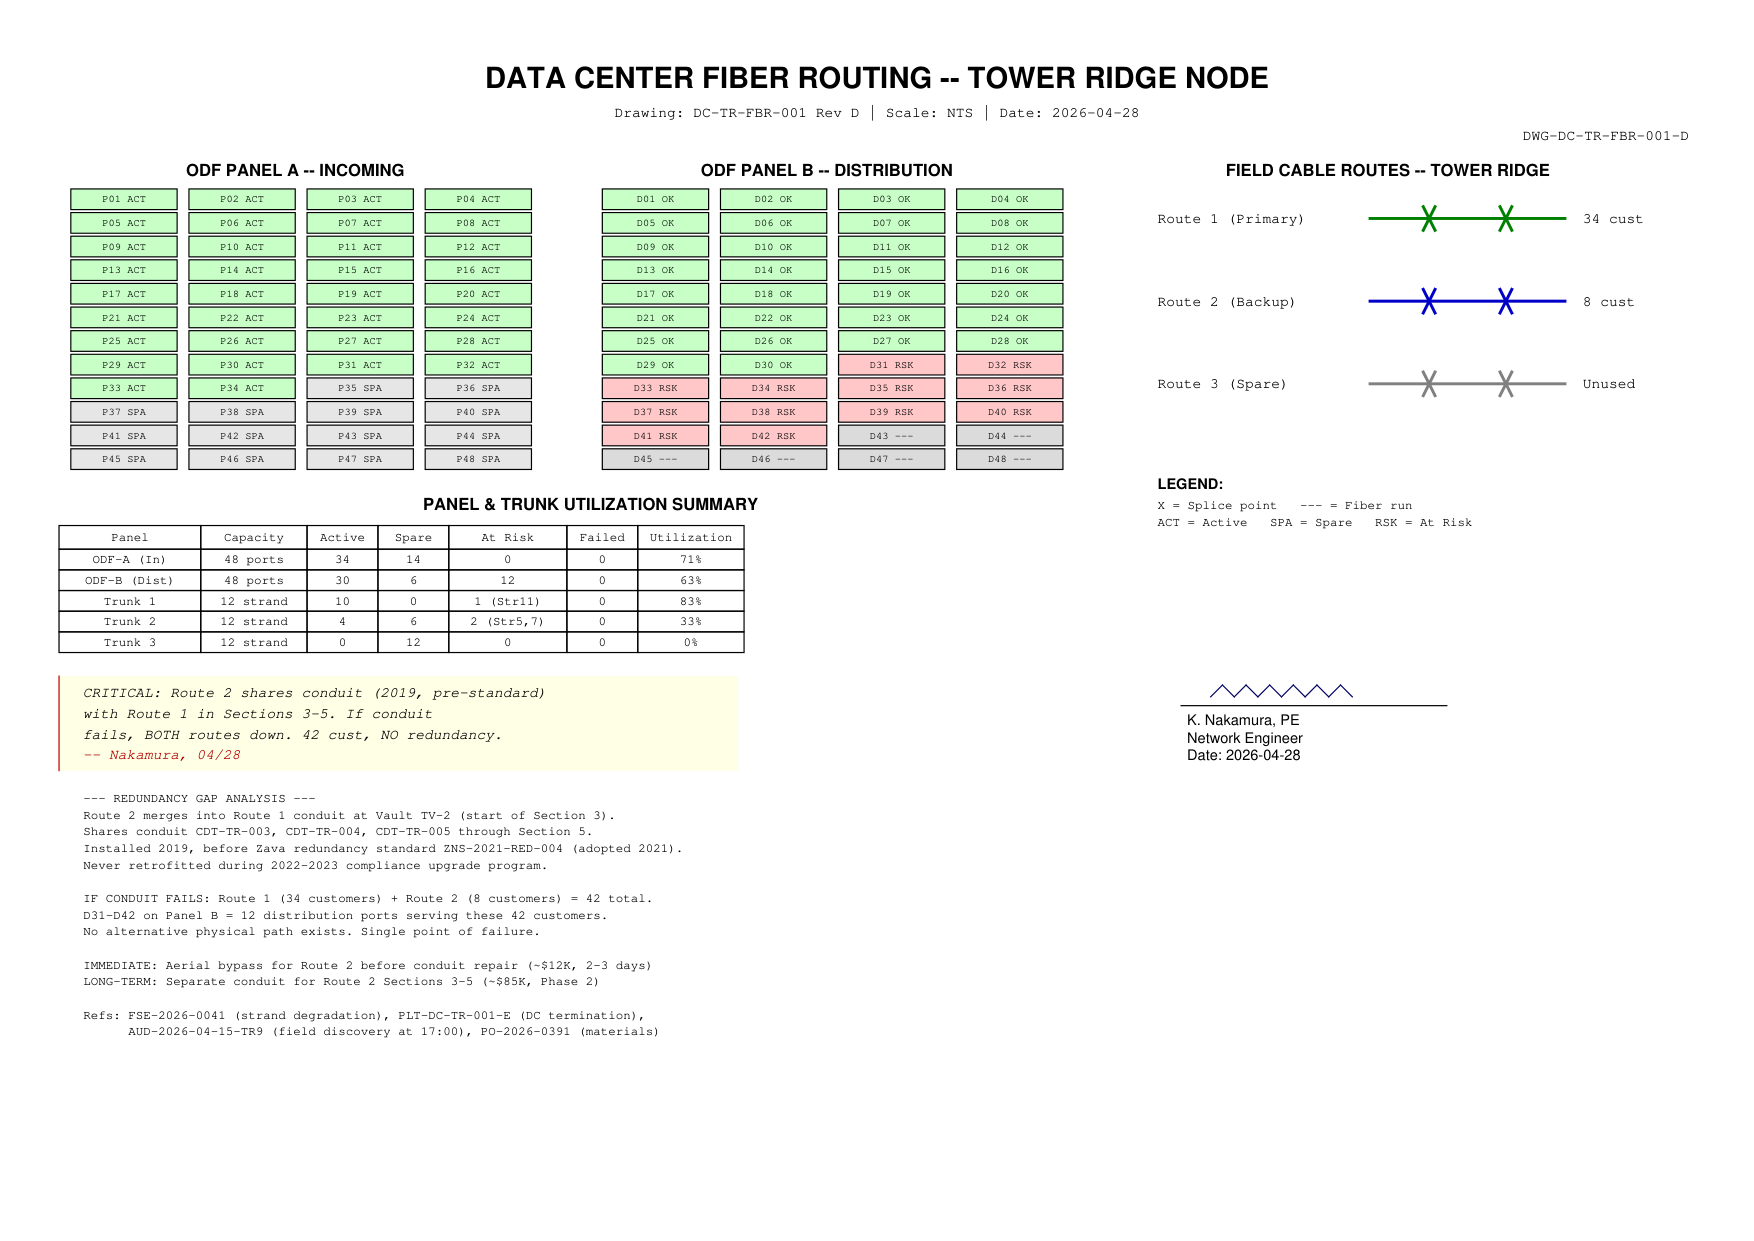

In [27]:
# Fiber Routing Diagram — with custom analyzer
fiber_routing = DOCS_DIR / "cl_v3_datacenter_fiber_routing_2026_04_28.pdf"
display(Markdown("### Fiber Routing Diagram — primary & backup paths"))
show_pdf(fiber_routing)

In [28]:
# Custom extraction: fiberRoutingAnalyzer
display(Markdown("### Custom Extraction: `fiberRoutingAnalyzer`"))

with open(fiber_routing, "rb") as f:
    routing_poller = client.begin_analyze_binary(
        analyzer_id="fiberRoutingAnalyzer", binary_input=f.read()
    )
routing_result = routing_poller.result()

rt_fields = routing_result.contents[0].fields
if rt_fields:
    for name, val in rt_fields.items():
        v = val.value if val.value is not None else val.value_string
        print(f"  {name}: {v}")

print("\n" + "─" * 60)
reasoning = agent_reason(
    to_llm_input(routing_result, include_markdown=False),
    "Fiber Routing Diagram — primary and backup paths with customer counts",
    "Is there redundancy? What happens if this conduit fails?"
)
print("AGENT [4/6]:")
print(reasoning)

### Custom Extraction: `fiberRoutingAnalyzer`

  RedundancyGap: Route 2 shares conduit with Route 1 in Sections 3-5
  AffectedCustomers: 42
  SinglePointOfFailure: Conduit CDT-TR-003, CDT-TR-004, CDT-TR-005 through Section 5 (shared by Route 1 and Route 2)
  RerouteOption: No alternative — full conduit replacement required

────────────────────────────────────────────────────────────
AGENT [4/6]:
- Both primary (Route 1) and backup (Route 2) fiber routes share the same conduit (CDT-TR-003, CDT-TR-004, CDT-TR-005) through Sections 3-5, creating a single point of failure.
- If this shared conduit fails, all 42 customers in the affected segment will lose service, as both routes are compromised.
- There is no alternative reroute option available; full conduit replacement is required to restore connectivity.
- The redundancy gap means that the backup path does not provide true protection in this segment.

Conclusion: There is no effective redundancy in Sections 3-5—failure of the shared conduit will result in total service loss for 42 c

### Equipment Spec & Materials Order — procurement data

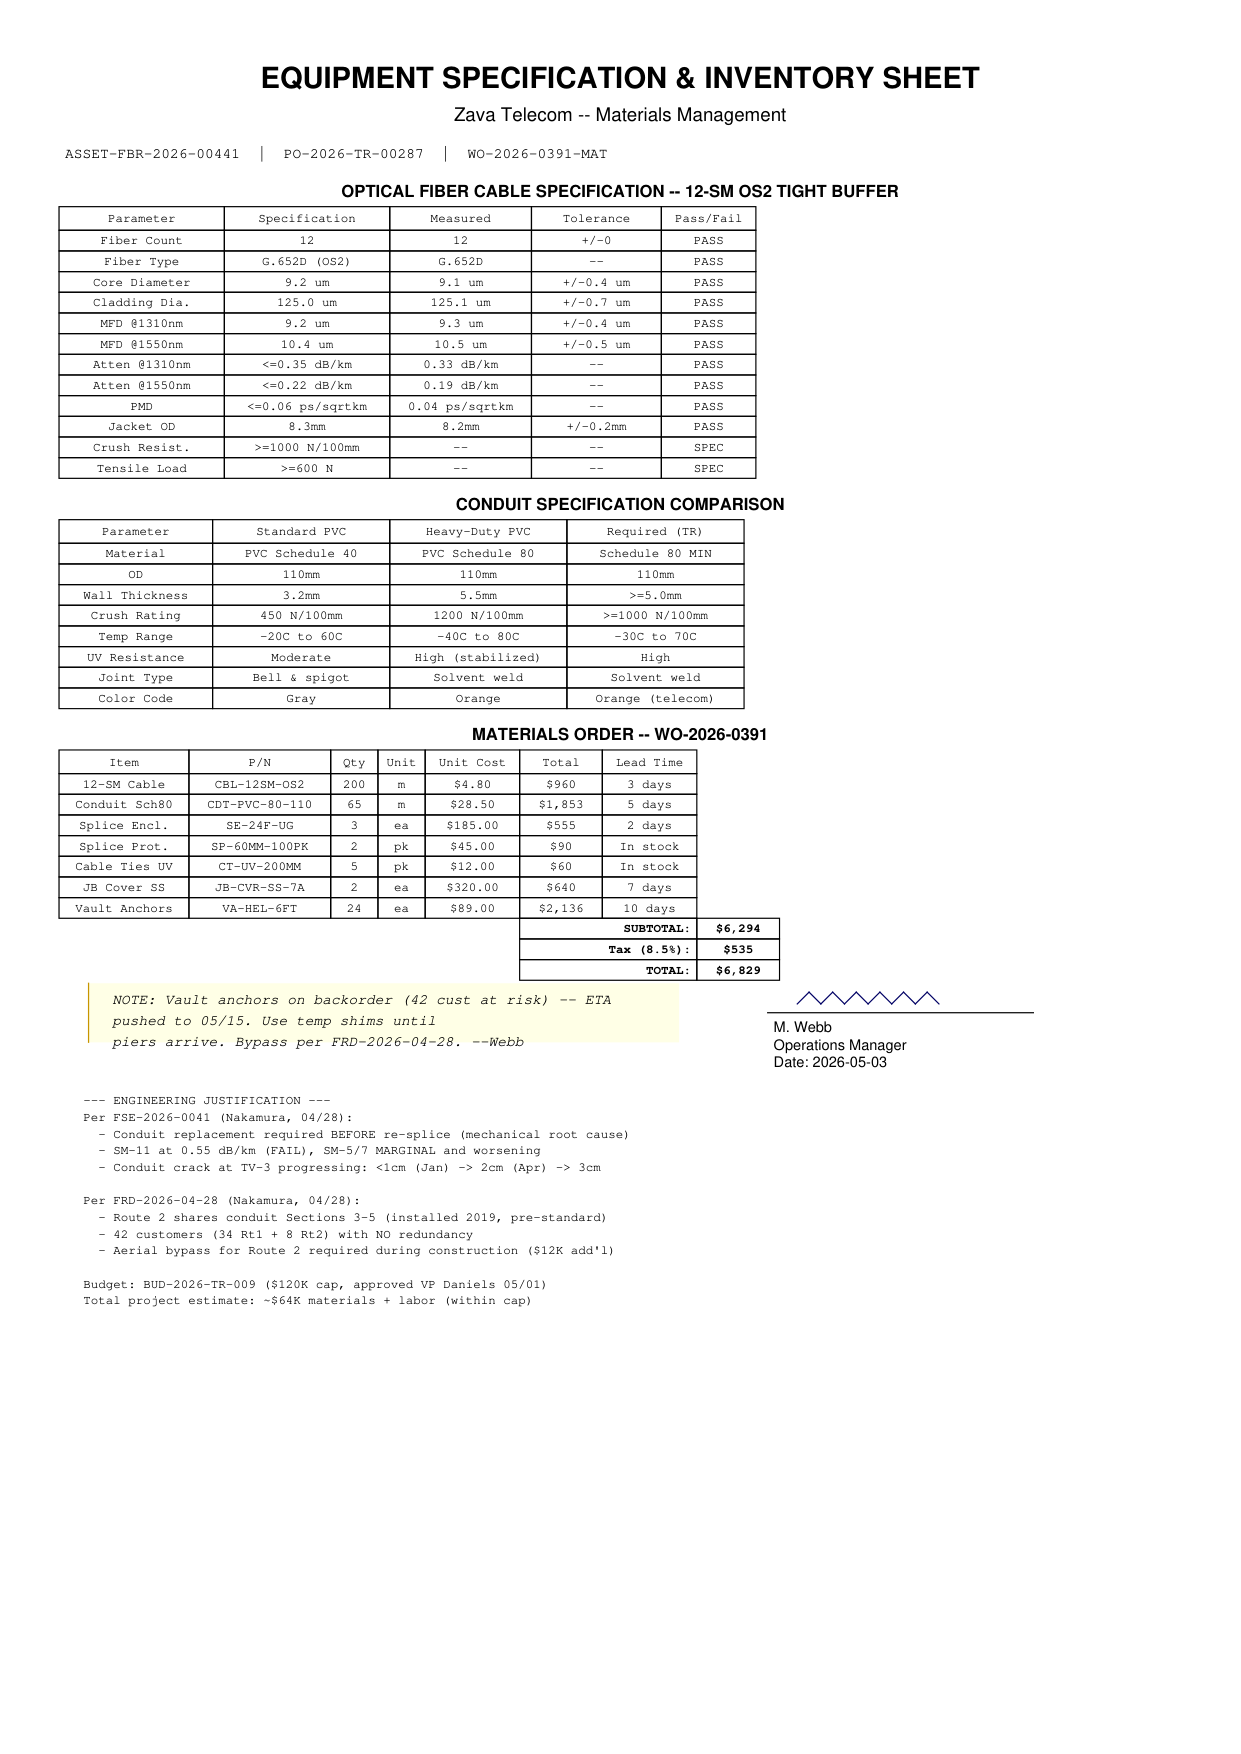

In [29]:
# Equipment Spec / Materials Order — with custom analyzer
equipment_spec = DOCS_DIR / "cl_v3_equipment_spec_sheet_2026_05_03.pdf"
display(Markdown("### Equipment Spec & Materials Order — procurement data"))
show_pdf(equipment_spec)

In [30]:
# Custom extraction: equipmentProcurementAnalyzer
display(Markdown("### Custom Extraction: `equipmentProcurementAnalyzer`"))

with open(equipment_spec, "rb") as f:
    equip_poller = client.begin_analyze_binary(
        analyzer_id="equipmentProcurementAnalyzer", binary_input=f.read()
    )
equip_result = equip_poller.result()

eq_fields = equip_result.contents[0].fields
if eq_fields:
    for name, val in eq_fields.items():
        v = val.value if val.value is not None else val.value_string
        print(f"  {name}: {v}")

print("\n" + "─" * 60)
reasoning = agent_reason(
    to_llm_input(equip_result, include_markdown=False),
    "Equipment Spec & Materials Order — procurement data with costs and lead times",
    "Are we within budget? Any schedule risks from backorders?"
)
print("AGENT [5/6]:")
print(reasoning)

### Custom Extraction: `equipmentProcurementAnalyzer`

  TotalCost: 6829.0
  BackorderRisk: Vault Anchors (VA-HEL-6FT): backorder (ETA pushed to 05/15)
  CriticalPathDays: 10
  BudgetVerdict: WITHIN BUDGET ($6829 of $120000)

────────────────────────────────────────────────────────────
AGENT [5/6]:
- The total procurement cost is $6,829, which is well within the allocated budget of $120,000.
- Vault Anchors (VA-HEL-6FT) are on backorder, with their estimated arrival date pushed to 05/15.
- The critical path for equipment delivery is 10 days, but the backorder could extend this timeline if anchors are essential for restoration.
- No other materials are flagged for backorder, minimizing broader supply chain risks.
- Schedule risk exists due to the delayed Vault Anchors, potentially impacting restoration for 42 customers.

Conclusion: We are within budget, but the Vault Anchor backorder (ETA 05/15) poses a schedule risk for Segment 9 restoration.


### Data Center Plant Diagram — facility layout with fiber paths

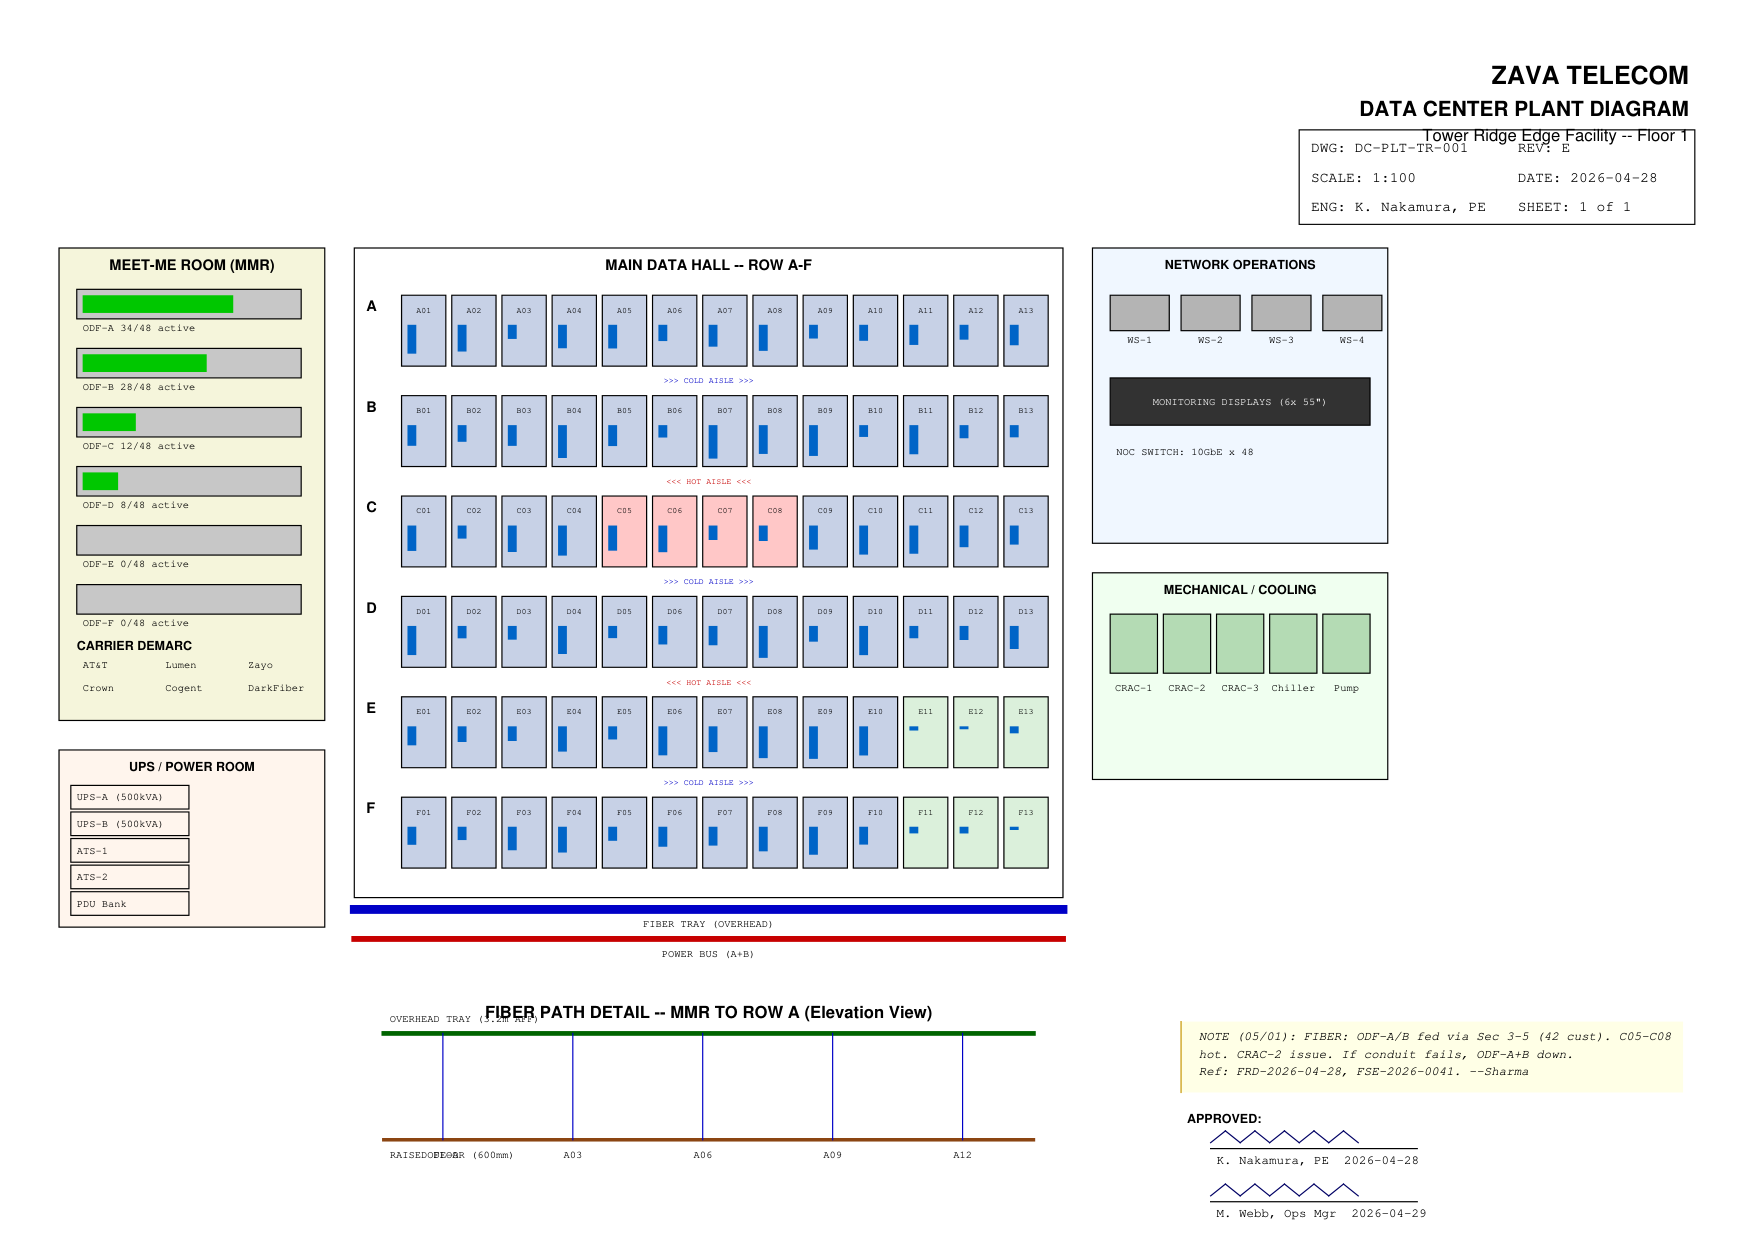

In [31]:
# Plant Diagram — with custom analyzer
plant_diagram = DOCS_DIR / "cl_v3_datacenter_plant_diagram_2026_04_28.pdf"
display(Markdown("### Data Center Plant Diagram — facility layout with fiber paths"))
show_pdf(plant_diagram)

In [32]:
# Custom extraction: plantDiagramAnalyzer
display(Markdown("### Custom Extraction: `plantDiagramAnalyzer`"))

with open(plant_diagram, "rb") as f:
    plant_poller = client.begin_analyze_binary(
        analyzer_id="plantDiagramAnalyzer", binary_input=f.read()
    )
plant_result = plant_poller.result()

pd_fields = plant_result.contents[0].fields
if pd_fields:
    for name, val in pd_fields.items():
        v = val.value if val.value is not None else val.value_string
        print(f"  {name}: {v}")

print("\n" + "─" * 60)
reasoning = agent_reason(
    to_llm_input(plant_result, include_markdown=False),
    "Data Center Plant Diagram — facility layout with fiber paths and cooling",
    "Where does fiber enter? Any secondary risks in the affected zone?"
)
print("AGENT [6/6]:")
print(reasoning)
print("\n   ✅ All 9 documents processed. Agent ready to synthesize.")

### Custom Extraction: `plantDiagramAnalyzer`

  FiberEntryPoint: CARRIER DEMARC
  ThermalRisk: CRAC-2 issue. If conduit fails, ODF-A+B down.
  AffectedZone: C05-C08
  FieldNotes: NOTE (05/01): FIBER: ODF-A/B fed via Sec 3-5 (42 cust). C05-C08 hot. CRAC-2 issue. If conduit fails, ODF-A+B down.
Ref: FRD-2026-04-28, FSE-2026-0041. --Sharma

APPROVED:

K. Nakamura, PE 2026-04-28

M. Webb, Ops Mgr 2026-04-29

────────────────────────────────────────────────────────────
AGENT [6/6]:
- Fiber enters the facility at the CARRIER DEMARC point, as indicated in the diagram.
- The affected zone is C05-C08, which is currently experiencing elevated temperatures ("hot"), increasing operational risk.
- There is a secondary risk from the CRAC-2 cooling unit; if it fails, both ODF-A and ODF-B (fiber distribution frames) will go down.
- The fiber serving 42 customers is routed via Sections 3-5, directly through the affected zone.
- If the conduit in C05-C08 fails, signal loss will impact both ODF-A and ODF-B, amplifying customer impact.

Conclusion: F

---

## Act 4 — The Agent Decides

Nine documents analyzed — three with generic extraction, six with custom analyzers. All structured evidence is now fed into **GPT-4.1** for three sequential steps:

1. **DIAGNOSE** — Synthesize all 9 documents into a root cause analysis
2. **IDENTIFY** — Build a materials/budget/schedule plan
3. **DISPATCH** — Draft a crew dispatch email with full traceability

> `to_llm_input()` converts each CU result into LLM-ready text. All 9 results are concatenated into agent context and sent to GPT-4.1 with role-specific system prompts.

In [33]:
# Assemble all 9 extraction results into full agent context for the synthesis steps
all_results = {
    "maintenance_log": maintenance_result,
    "audio_transcript": audio_result,
    "inspection_photos": photos_result,
    "photo_log": photo_log_result,
    "video_inspection": video_result,
    "splice_sheet": splice_result,
    "fiber_routing": routing_result,
    "equipment_spec": equip_result,
    "plant_diagram": plant_result,
}

agent_context_parts = []
total_chars = 0
print("Assembling full agent context via to_llm_input():\n")
for name, result in all_results.items():
    text = to_llm_input(result, metadata={"source": name, "incident": "INC-2026-0391"})
    agent_context_parts.append(f"=== Document: {name} ===\n{text}")
    total_chars += len(text)
    print(f"  {name:25s} → {len(text):>6,} chars")

FULL_CONTEXT = "\n\n".join(agent_context_parts)

print(f"\n✅ Total context: {total_chars:,} chars (~{total_chars // 4:,} tokens)")
print(f"   9 complex PDFs → structured agent context ready for synthesis")

Assembling full agent context via to_llm_input():

  maintenance_log           →  5,176 chars
  audio_transcript          →  3,415 chars
  inspection_photos         →  4,290 chars
  photo_log                 →  4,167 chars
  video_inspection          →  3,640 chars
  splice_sheet              →  3,748 chars
  fiber_routing             →  4,560 chars
  equipment_spec            →  4,709 chars
  plant_diagram             →  2,050 chars

✅ Total context: 35,755 chars (~8,938 tokens)
   9 complex PDFs → structured agent context ready for synthesis


In [34]:
# Step 1: DIAGNOSE
display(Markdown("### Step 1: DIAGNOSE — Root Cause Analysis"))

DIAGNOSE_SYSTEM = """You are the Fiber Cut Response Agent for Zava Telecom. Your role: synthesize document evidence into a root cause diagnosis.

You have been given structured extraction results from 9 field documents processed by Azure Content Understanding. Each document was analyzed with either the generic prebuilt-documentSearch analyzer or a purpose-built custom analyzer.

Produce a DIAGNOSIS report with:
- Location and severity
- Root cause (specific infrastructure element)
- Affected strands with loss measurements
- Customers at risk and redundancy status
- Evidence chain: list each document source that corroborates your conclusion
- Final verdict (one sentence)

Be precise. Cite specific values from the extracted fields. Use the format:
DIAGNOSIS: [incident ID]
Then structured sections."""

diagnose_response = agent_client.chat.completions.create(
    model=AGENT_MODEL,
    messages=[
        {"role": "system", "content": DIAGNOSE_SYSTEM},
        {"role": "user", "content": f"Incident: INC-2026-0391\n\nDocument evidence:\n\n{FULL_CONTEXT}"},
    ],
    temperature=0.2,
    max_tokens=2000,
)

diagnosis_text = diagnose_response.choices[0].message.content
print(diagnosis_text)

### Step 1: DIAGNOSE — Root Cause Analysis

DIAGNOSIS: INC-2026-0391

---

**Location and Severity**

- **Location:** Tower Ridge Corridor, Site B, Segment 9 (Pole TR-38 to JB-9B), specifically Vault TV-3 and conduit Sections 3-5.
- **Severity:** CRITICAL. Immediate risk of total service loss for 42 customers due to a progressing conduit crack and structural failure at Vault TV-3, with no redundancy.

---

**Root Cause (Specific Infrastructure Element)**

- **Root Cause:** Mechanical failure of the shared underground conduit (CDT-TR-003, CDT-TR-004, CDT-TR-005) at Vault TV-3, caused by a worsening crack and displacement of the protective sleeve, resulting in micro-bends and elevated fiber loss.
- **Infrastructure Element:** Shared conduit installed in 2019 (pre-ZNS-2021-RED-004 redundancy standard), never retrofitted.

---

**Affected Strands with Loss Measurements**

- **Cable Type:** 12-SM OS2 Tight Buffer
- **Affected Strands:**
  - SM-5 (Slate): 0.52 dB/km (MARGINAL)
  - SM-7 (Red): 0.48 dB/km (MARGINAL)
  - SM-11 (Rose): 0.

In [35]:
# Step 2: IDENTIFY
display(Markdown("### Step 2: IDENTIFY — Materials, Budget & Schedule"))

IDENTIFY_SYSTEM = """You are the Fiber Cut Response Agent for Zava Telecom. Your role: build a materials and budget plan from the equipment spec extraction and diagnosis.

You have the full document context AND the diagnosis from your previous step.

Produce a MATERIALS PLAN with:
- Budget cap and approval reference
- Table of materials: item, part number, quantity, cost, availability status
- Total cost vs budget verdict
- Schedule risks (backorders, lead times)
- Mitigation strategy for any delays
- Crew assignment recommendation

Be precise. Use actual part numbers and costs from the equipment spec extraction."""

identify_response = agent_client.chat.completions.create(
    model=AGENT_MODEL,
    messages=[
        {"role": "system", "content": IDENTIFY_SYSTEM},
        {"role": "user", "content": f"Incident: INC-2026-0391\n\nDiagnosis:\n{diagnosis_text}\n\nFull document evidence:\n\n{FULL_CONTEXT}"},
    ],
    temperature=0.2,
    max_tokens=2000,
)

identify_text = identify_response.choices[0].message.content
print(identify_text)

### Step 2: IDENTIFY — Materials, Budget & Schedule

## MATERIALS PLAN — Incident INC-2026-0391 (Tower Ridge Corridor, Site B, Segment 9)

---

### Budget Cap & Approval Reference

- **Budget Cap:** $120,000 (corridor rehab, BUD-2026-TR-009)
- **Approval:** VP Daniels, 2026-05-01 (see maintenance_log addendum, plant_diagram, equipment_spec)
- **Materials Order Reference:** PO-2026-0391 (Webb, 05/03)
- **Engineering Justification:** FSE-2026-0041, FRD-2026-04-28

---

### Materials Table

| Item                | Part Number        | Quantity | Unit Cost | Total Cost | Availability Status         | Lead Time      |
|---------------------|-------------------|----------|-----------|-----------|----------------------------|----------------|
| 12-SM OS2 Cable     | CBL-12SM-OS2      | 200 m    | $4.80     | $960      | In stock                   | 3 days         |
| Conduit Sch80 110mm | CDT-PVC-80-110    | 65 m     | $28.50    | $1,853    | In stock                   | 5 days         |
| Splice Enclosure    | SE-24F-UG         | 3 ea     | $1

In [36]:
# Step 3: DISPATCH
display(Markdown("### Step 3: DISPATCH — Resolution Email"))

DISPATCH_SYSTEM = """You are the Fiber Cut Response Agent for Zava Telecom. Your role: draft a dispatch email to the repair crew.

You have the diagnosis and materials plan from your previous steps. Now produce a professional dispatch email that a crew supervisor can act on immediately.

The email must include:
- To/Cc/Subject headers
- Priority and start date
- Scope of work (bullet points)
- Root cause summary with document references (use document IDs like FSE-2026-0041, FRD-2026-04-28 if found in the data)
- Risk callout (customer impact, redundancy status)
- Pre-work checklist
- Budget summary

End with an automated signature line showing this was generated by the agent.
Format as a ready-to-send email."""

dispatch_response = agent_client.chat.completions.create(
    model=AGENT_MODEL,
    messages=[
        {"role": "system", "content": DISPATCH_SYSTEM},
        {"role": "user", "content": (
            f"Incident: INC-2026-0391\n\n"
            f"Diagnosis:\n{diagnosis_text}\n\n"
            f"Materials Plan:\n{identify_text}\n\n"
            f"Full document evidence:\n\n{FULL_CONTEXT}"
        )},
    ],
    temperature=0.3,
    max_tokens=2000,
)

dispatch_text = dispatch_response.choices[0].message.content
print(dispatch_text)

print("\n" + "═" * 60)
print("Input: 9 documents × to_llm_input() → structured context")
print("   The agent reasoned from CU extractions — no pre-written templates.")
print("═" * 60)

### Step 3: DISPATCH — Resolution Email

**To:** Team A (Fiber Crew Supervisor), GeoCorp Crew Lead  
**Cc:** K. Nakamura (Engineering), P. Sharma (Field Tech), M. Webb (Ops Manager), VP Daniels (Budget), NOC Operations  
**Subject:** [PRIORITY: CRITICAL] Dispatch — Conduit Replacement & Fiber Restoration, Tower Ridge Corridor Site B, Segment 9 (INC-2026-0391)

---

**Priority:** CRITICAL  
**Start Date:** Immediate — Target Crew Mobilization: 2026-05-08 (materials ETA aligns; vault anchors temp shim strategy in place)

---

**Scope of Work — Tower Ridge Corridor Site B, Segment 9 (Pole TR-38 to JB-9B, Vault TV-3, Sections 3-5):**

- Remove failed underground conduit (CDT-TR-003/004/005) at Vault TV-3 and Sections 3-5.
- Install new Schedule 80 PVC conduit (65m, CDT-PVC-80-110) per engineering spec.
- Replace 12-SM OS2 tight buffer cable (200m, CBL-12SM-OS2); perform full splicing and loss verification.
- Deploy new splice enclosures (SE-24F-UG x3), splice protectors, cable ties, and JB covers.
- Stabilize Vault TV-3 using tem

---

## Under the Hood: `to_llm_input()` — The Bridge Between CU and Your Agent

The SDK helper converts any `AnalysisResult` into agent-ready text. A single function call handles formatting, field serialization, and token optimization:

| Mode | Use Case | Token Impact |
|------|----------|-------------|
| `to_llm_input(result)` | Full reasoning context | Complete |
| `to_llm_input(result, include_markdown=False)` | Routing/triage decisions | **Significantly smaller** |
| `to_llm_input(result, include_fields=False)` | Summarization tasks | No field overhead |
| `to_llm_input(result, metadata={...})` | RAG pipelines | Source tracking |

> With 9 documents in this scenario, using `include_markdown=False` yields substantially smaller context — sufficient for routing decisions at a fraction of the token cost.

In [37]:
# Default output: YAML front matter + markdown body
display(Markdown("### Default: Full output"))
full_output = to_llm_input(maintenance_result)
print(f"Length: {len(full_output):,} chars\n")
print(full_output[:1500])

### Default: Full output

Length: 5,128 chars

---
contentType: document
pages: 1
fields:
  Summary: This document is a site maintenance log for the Tower Ridge Corridor Site B, Segment 9, covering the second quarter of 2026. It details maintenance activities including inspections, testing, repairs, and engineering assessments performed by various technicians and teams, along with their labor hours, rates, and costs. The log also references related incidents, repair and condition reports, and ongoing work orders. An addendum notes total reactive spending, corridor rehabilitation approval, and upcoming replacement work. The document includes verification checklists and cross-references to related documents and media.
rai_warnings:
- code: LLMStats
  message: 'completion calls: 2; completion latency: 2.09s'
---
<!-- page 1 -->

# SITE MAINTENANCE LOG -- TOWER RIDGE CORRIDOR Site B -- Segment 9 (Pole TR-38 to JB-9B) | Log Period: 2026-Q2

LOG-TR-2026-Q2


## MAINTENANCE ACTIVITY LOG


<table>
<tr>
<th>Date</th>
<t

In [38]:
# Fields-only: minimal tokens for agent routing/triage
display(Markdown("### Fields Only: Agent triage (token reduction)"))
fields_only = to_llm_input(maintenance_result, include_markdown=False)
reduction = 100 - len(fields_only) * 100 // len(full_output)
print(f"Length: {len(fields_only):,} chars ({reduction}% reduction from {len(full_output):,})\n")
print(fields_only)

### Fields Only: Agent triage (token reduction)

Length: 773 chars (85% reduction from 5,128)

---
contentType: document
pages: 1
fields:
  Summary: This document is a site maintenance log for the Tower Ridge Corridor Site B, Segment 9, covering the second quarter of 2026. It details maintenance activities including inspections, testing, repairs, and engineering assessments performed by various technicians and teams, along with their labor hours, rates, and costs. The log also references related incidents, repair and condition reports, and ongoing work orders. An addendum notes total reactive spending, corridor rehabilitation approval, and upcoming replacement work. The document includes verification checklists and cross-references to related documents and media.
rai_warnings:
- code: LLMStats
  message: 'completion calls: 2; completion latency: 2.09s'
---


In [39]:
# With metadata: RAG pipeline integration
display(Markdown("### With Metadata: Source tracking for RAG"))
with_metadata = to_llm_input(
    splice_result,
    metadata={
        "source": "cl_v3_engineering_splice_sheet_2026_04_28.pdf",
        "incident": "INC-2026-0391",
        "site": "Tower Ridge Corridor - Segment 9",
        "analyzed_by": "Fiber Cut Response Agent",
    },
)

# Show YAML front matter
yaml_end = with_metadata.find("---", 4)
print(with_metadata[:yaml_end + 3] if yaml_end > 0 else with_metadata[:1000])
print(f"\n... + {len(with_metadata) - yaml_end - 3:,} chars of markdown body")

### With Metadata: Source tracking for RAG

---
contentType: document
source: cl_v3_engineering_splice_sheet_2026_04_28.pdf
incident: INC-2026-0391
site: Tower Ridge Corridor - Segment 9
analyzed_by: Fiber Cut Response Agent
pages: 1
fields:
  CableType: 12-SM OS2 Tight
  StrandCount: 12
  FailedStrands: SM-5 (Slate, 0.52 dB/km, MARGINAL); SM-7 (Red, 0.48 dB/km, MARGINAL); SM-11 (Rose, 0.55 dB/km, FAIL)
  FailureMode: Conduit is root cause.
  MaxLoss: 0.55
  EngineeringRecommendation: Aerial bypass for Route 2 BEFORE conduit replacement.
rai_warnings:
- code: LLMStats
  message: 'completion calls: 2; completion latency: 15.75s'
---

... + 3,263 chars of markdown body


---

## Act 5 — Microsoft Agent Framework Integration

Acts 1–4 used a **manual pipeline**: explicit CU calls, explicit `to_llm_input()` formatting, manual context assembly. This provides full control, but involves more moving parts.

The **Microsoft Agent Framework** (`agent-framework-azure-contentunderstanding`) wraps this lifecycle into a single **context provider**:

```
  Manual Pipeline (Acts 1-4)              Agent Framework (Act 5)
  ─────────────────────                   ─────────────────────────
  client.begin_analyze_binary()           ┐
  poller.result()                         │
  to_llm_input(result)                    ├── ContentUnderstandingContextProvider
  context_parts.append(text)              │   (handles all of this automatically)
  agent_client.chat.completions.create()  ┘
```

**Differences:**
- No explicit CU calls — the provider intercepts file attachments
- No `to_llm_input()` — the provider formats and injects context automatically
- No manual context assembly — the framework manages the LLM conversation
- Multi-turn caching — follow-up questions reuse cached analysis results

In [47]:
%pip install agent-framework-azure-contentunderstanding agent-framework-foundry --pre --quiet

Note: you may need to restart the kernel to use updated packages.


In [48]:
import asyncio
from agent_framework import Agent, AgentSession, Content, Message
from agent_framework.foundry import ContentUnderstandingContextProvider, FoundryChatClient
from azure.identity import DefaultAzureCredential as DACred

display(Markdown("### Agent Framework Setup"))

# The CU context provider — handles CU analysis as part of the agent loop
cu_provider = ContentUnderstandingContextProvider(
    endpoint=ENDPOINT,
    credential=AzureKeyCredential(KEY) if KEY else DACred(),
    analyzer_id="prebuilt-documentSearch",  # General-purpose: tables, figures, markdown
    max_wait=None,  # Block until extraction completes (no background deferral)
)

# The LLM client — Agent Framework's wrapper around Azure OpenAI
# FoundryChatClient uses the Responses API via AIProjectClient,
# which requires a token credential (AzureKeyCredential is not supported here).
foundry_credential = DACred()
foundry_client = FoundryChatClient(
    project_endpoint=ENDPOINT,
    model=AGENT_MODEL,
    credential=foundry_credential,
)

print("✅ ContentUnderstandingContextProvider configured")
print(f"   Endpoint: {ENDPOINT}")
print(f"   Analyzer: prebuilt-documentSearch")
print(f"   Model: {AGENT_MODEL}")
print(f"\n   With this pattern, the provider handles:")
print(f"   • CU analysis when files are attached")
print(f"   • Formatting results for the LLM")
print(f"   • Injecting context into the conversation")
print(f"   • Caching results across turns")

### Agent Framework Setup

✅ ContentUnderstandingContextProvider configured
   Endpoint: https://mmi-usw3-eft-foundry.services.ai.azure.com/
   Analyzer: prebuilt-documentSearch
   Model: gpt-4.1

   With this pattern, the provider handles:
   • CU analysis when files are attached
   • Formatting results for the LLM
   • Injecting context into the conversation
   • Caching results across turns


In [49]:
# The entire 9-document workflow — collapsed into one agent.run() call
display(Markdown("### One Call: 9 Documents → Diagnosis + Dispatch"))
print("Attaching all 9 PDFs to a single message.")
print("The CU provider will automatically analyze each one and inject results into context.\n")

# Collect all document PDFs
all_pdfs = sorted(DOCS_DIR.glob("cl_v3_*.pdf"))
print(f"Documents attached: {len(all_pdfs)}")
for pdf in all_pdfs:
    print(f"  {pdf.name}")

async def run_agent_framework_demo():
    async with cu_provider:
        # Create the agent with CU as a context provider
        agent = Agent(
            client=foundry_client,
            name="FiberCutResponseAgent",
            instructions=(
                "You are the Fiber Cut Response Agent for Zava Telecom. "
                "You are responding to incident INC-2026-0391: signal degradation detected "
                "on Tower Ridge Corridor, Site B, Segment 9. 42 customers at risk — "
                "primary and backup share conduit, no redundancy path available.\n\n"
                "Analyze all attached documents and produce:\n"
                "1. ROOT CAUSE DIAGNOSIS — what failed and why\n"
                "2. MATERIALS PLAN — what's needed, cost, schedule risks\n"
                "3. DISPATCH SUMMARY — crew assignment with key details\n\n"
                "Be precise. Cite specific values from the documents."
            ),
            context_providers=[cu_provider],
        )

        session = AgentSession()

        # Build message with all 9 PDFs attached
        contents = [
            Content.from_text(
                "Incident INC-2026-0391 is critical. Analyze all attached field documents "
                "and provide: (1) root cause diagnosis, (2) materials/budget plan, "
                "(3) dispatch summary for the repair crew."
            ),
        ]
        for pdf in all_pdfs:
            contents.append(
                Content.from_data(
                    pdf.read_bytes(),
                    "application/pdf",
                    additional_properties={"filename": pdf.name},
                )
            )

        # ONE CALL — CU analyzes all docs, injects into context, agent reasons
        print(f"\nRunning agent (CU will analyze {len(all_pdfs)} documents automatically)...")
        response = await agent.run(
            Message(role="user", contents=contents),
            session=session,
        )

        usage = response.usage_details or {}
        print(f"\n{'═' * 60}")
        print(f"AGENT RESPONSE:")
        print(f"{'═' * 60}")
        print(sanitize(response.text))
        print(f"\n{'─' * 60}")
        print(f"Input tokens: {usage.get('input_token_count', 'N/A')}")
        print(f"Output tokens: {usage.get('output_token_count', 'N/A')}")

        return session, agent

# Run the async demo (await directly — Jupyter already has an event loop)
session, agent = await run_agent_framework_demo()

### One Call: 9 Documents → Diagnosis + Dispatch

Attaching all 9 PDFs to a single message.
The CU provider will automatically analyze each one and inject results into context.

Documents attached: 9
  cl_v3_datacenter_fiber_routing_2026_04_28.pdf
  cl_v3_datacenter_plant_diagram_2026_04_28.pdf
  cl_v3_engineering_splice_sheet_2026_04_28.pdf
  cl_v3_equipment_spec_sheet_2026_05_03.pdf
  cl_v3_inspection_photos_2026_05_02.pdf
  cl_v3_maintenance_log_2026_Q2.pdf
  cl_v3_site_b_audio_transcript_2026_04_15.pdf
  cl_v3_site_b_photo_log_2026_04_10.pdf
  cl_v3_site_b_video_inspection_2026_04_10.pdf

Running agent (CU will analyze 9 documents automatically)...

════════════════════════════════════════════════════════════
AGENT RESPONSE:
════════════════════════════════════════════════════════════
**Incident INC-2026-0391 — Tower Ridge Corridor, Site B, Segment 9**  
**Customer Risk:** 42 customers (primary + backup; no redundancy; shared conduit Sections 3-5)

---

## 1. ROOT CAUSE DIAGNOSIS

**Primary Failure:**  
- **Vault TV-3 conduit crac

In [50]:
# Multi-turn: Follow-up question — no re-analysis needed
display(Markdown("### Multi-Turn: Follow-Up Without Re-Analysis"))
print("The CU provider caches extraction results in the session.")
print("Follow-up questions use cached context — no additional CU calls.\n")

async def run_followup():
    async with cu_provider:
        # Re-create agent (same config)
        agent = Agent(
            client=foundry_client,
            name="FiberCutResponseAgent",
            instructions=(
                "You are the Fiber Cut Response Agent for Zava Telecom. "
                "You have already analyzed all documents for INC-2026-0391. "
                "Answer follow-up questions using the cached document context."
            ),
            context_providers=[cu_provider],
        )

        # Follow-up — the provider already has all 9 documents cached
        followup_response = await agent.run(
            Message(role="user", contents=[
                Content.from_text(
                    "If Vault TV-3 fails entirely, what's the fallback? "
                    "How many customers would go dark before we can reroute?"
                ),
            ]),
            session=session,
        )

        usage = followup_response.usage_details or {}
        print(f"FOLLOW-UP RESPONSE:")
        print(f"{'─' * 60}")
        print(sanitize(followup_response.text))
        print(f"\n{'─' * 60}")
        print(f"Input tokens: {usage.get('input_token_count', 'N/A')}")
        print(f"No CU re-analysis — cached from previous turn")

await run_followup()

### Multi-Turn: Follow-Up Without Re-Analysis

The CU provider caches extraction results in the session.
Follow-up questions use cached context — no additional CU calls.

FOLLOW-UP RESPONSE:
────────────────────────────────────────────────────────────
**Vault TV-3 Failure — Fallback & Customer Impact**

### **1. Fallback Options**

**Field Evidence:**  
- **No native redundancy:**  
  - Both Route 1 (34 customers) and Route 2 (8 customers) share the same conduit (Sections 3–5) through Vault TV-3.  
    - Reference:  
      - cl_v3_datacenter_fiber_routing_2026_04_28.pdf ("Redundancy Gap Analysis": “No alternative physical path exists. Single point of failure.”)
      - cl_v3_engineering_splice_sheet_2026_04_28.pdf (“Route 2 shares conduit with Route 1 … NO redundancy.”)
- **Fallback plan:**  
  - **Aerial bypass for Route 2 backup** recommended as immediate (temporary) action.
    - Cost: ~$12,000, install time 2–3 days (cl_v3_datacenter_fiber_routing_2026_04_28.pdf).
    - Only covers Route 2 (8 customers). Route 1 remains unprote

### Comparison: Two Patterns for Using CU with Agents

| | Acts 1–4 (SDK pipeline) | Act 5 (Agent Framework) |
|---|---|---|
| **CU calls** | Explicit | Provider handles on attachment |
| **Formatting** | `to_llm_input()` with options | Provider formats automatically |
| **Context assembly** | You build the prompt | Framework manages |
| **Multi-turn** | You manage state | Provider caches across turns |
| **Best for** | Custom extraction, per-doc routing, token control | Multi-turn chat, rapid prototyping |

> Both patterns use the same CU service underneath. The SDK pipeline provides granular control; the Agent Framework pattern abstracts the integration so you can focus on agent behavior.

---

## Recap

| Act | Agent Task | CU Capability Demonstrated |
|-----|-----------|----------------------------|
| **1** | Assess incident history | Tables, selection marks, QR codes, signatures |
| **2** | Verify damage visually | Embedded images → AI-generated figure captions |
| **3** | Extract decision-critical fields | **Custom analyzers** with inferred fields (reasoning, not OCR) |
| **4** | Diagnose and dispatch | `to_llm_input()` → 9 docs become agent context → resolution |
| **5** | Agent Framework pattern | CU as a context provider, multi-turn caching |

### Developer Takeaways

1. **Start with `prebuilt-documentSearch`** — it handles tables, figures, barcodes, selection marks, and signatures out of the box. No schema required.

2. **Use custom analyzers when the agent needs decision-ready fields.** Fields like `DispatchUrgency`, `DamageProgression`, and `BudgetVerdict` are not in the document — CU **reasons** about them using the completion model you specify.

3. **Use the classifier for production routing.** A single API call classifies the document type, routes to the correct analyzer, and returns structured fields. No branching logic in application code.

4. **`to_llm_input()` is the SDK-level integration point.** It converts any CU result into clean YAML+markdown consumable by any LLM. Use `include_markdown=False` for significant token savings in routing scenarios.

5. **Agent Framework as an alternative pattern.** `ContentUnderstandingContextProvider` integrates CU directly into the agent conversation loop — attachment detection, analysis, formatting, injection, and caching.

6. **End-to-end result:** 9 complex PDFs → structured evidence → automated diagnosis → repair crew dispatched.

---

*Built with: Azure AI Content Understanding (preview) + `azure-ai-contentunderstanding` 1.2.0b1 + `agent-framework-azure-contentunderstanding`*